# Part 3 — Feature Engineering, Selection, Ridge Tuning & Experiments

### Imports

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from sklearn.linear_model import *

### Loading Data

In [26]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

### Data Merging, NaN Handling & Station Split

In [27]:
# 1. Convert datetime columns
df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_holidays["datetime"] = pd.to_datetime(df_holidays["date"])

# 2. Merge bikes and weather
df_merged = pd.merge(df_bike_counts, df_weather, on="datetime", how="left")

# 3. Extract date and time from df_merged (not df - that doesn't exist yet!)
df_merged["date"] = df_merged["datetime"].dt.date
df_merged["time"] = df_merged["datetime"].dt.time

# 4. Add holiday info
df_holidays["date"] = df_holidays["datetime"].dt.date
df_holidays["holiday"] = True
df_merged = pd.merge(df_merged, df_holidays[["date", "holiday"]], on="date", how="left")
df_merged["holiday"] = df_merged["holiday"].fillna(False)

# 5. Add weekend and workday flags
df_merged["date_dt"] = pd.to_datetime(df_merged["date"])
df_merged["is_weekend"] = df_merged["date_dt"].dt.weekday.isin([5, 6]).astype(int)
df_merged["is_workday"] = ((df_merged["is_weekend"] == 0) & (~df_merged["holiday"])).astype(int)

# 6. Sort and forward fill (use df_merged consistently)
df_merged = df_merged.sort_values("datetime").copy()
df_merged.ffill(inplace=True)

# 7. Fill NaN bike counts using your function
col = "bike_count"

def fill_nan_same_hour_workdays(group):
    group = group.sort_values("date_dt").copy()
    values = group[col].copy()
    
    for i in group.index[group[col].isna()]:
        pos = group.index.get_loc(i)
        
        prev_vals = group.iloc[:pos]
        prev_vals = prev_vals[
            (prev_vals["is_workday"] == 1) & (prev_vals[col].notna())
        ][col].tail(5)
        
        next_vals = group.iloc[pos+1:]
        next_vals = next_vals[
            (next_vals["is_workday"] == 1) & (next_vals[col].notna())
        ][col].head(5)
        
        neighbors = pd.concat([prev_vals, next_vals])
        
        if len(neighbors) > 0:
            values.loc[i] = neighbors.mean()
    
    group[col] = values
    return group

parts = []
for (station, time), group in df_merged.groupby(["station", "time"]):
    filled = fill_nan_same_hour_workdays(group)
    parts.append(filled)

df_merged = pd.concat(parts, ignore_index=True)


station = "Langebro" 

df_training = df_merged[(df_merged["datetime"].dt.year == 2021) & (df_merged["station"] == station)].copy()
df_validating = df_merged[(df_merged["datetime"].dt.year == 2022) & (df_merged["station"] == station)].copy()
df_testing = df_merged[(df_merged["datetime"].dt.year == 2023) & (df_merged["station"] == station)].copy()

/var/folders/pt/srr73kjx1pdbnpwylcyp844r0000gn/T/ipykernel_6270/1355457159.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["holiday"] = df_merged["holiday"].fillna(False)


### Helper Functions

In [28]:
def linear_reg(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

def ridge_reg(X, y, lam):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

def calculate_RMSE(X, w, y_true):
    y_pred = np.maximum((X @ w).flatten(), 0)
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def standardize_train(X):
    # leave intercept (col 0) untouched
    mu = X[:, 1:].mean(axis=0)
    sigma = X[:, 1:].std(axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std, mu, sigma

def standardize_apply(X, mu, sigma):
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std

### Feature Engineering — Base Candidates

In [29]:
def add_features(df):
    df = df.copy()
    h   = df["datetime"].dt.hour
    doy = df["datetime"].dt.dayofyear
    dow = df["datetime"].dt.dayofweek

    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}"] = np.sin(2 * np.pi * k * h / 24)
        df[f"h_cos{k}"] = np.cos(2 * np.pi * k * h / 24)

    df["d_sin1"] = np.sin(2 * np.pi * doy / 365)
    df["d_cos1"] = np.cos(2 * np.pi * doy / 365)
    df["d_sin2"] = np.sin(4 * np.pi * doy / 365)
    df["d_cos2"] = np.cos(4 * np.pi * doy / 365)

    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    df["is_weekend"] = (dow >= 5).astype(float)
    df["is_holiday"] = df["holiday"].astype(float)
    df["is_workday"] = ((1 - df["is_weekend"]) * (1 - df["is_holiday"])).astype(float)

    df["temp"]       = df["temperature_C"]
    df["temp_sq"]    = df["temperature_C"] ** 2
    df["wind"]       = df["wind_speed_ms"]
    df["wind_sq"]    = df["wind_speed_ms"] ** 2
    df["precip"]     = df["precipitation_mm"]
    df["log_precip"] = np.log1p(df["precipitation_mm"])
    df["is_raining"] = (df["precipitation_mm"] > 0.1).astype(float)

    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}_wd"] = df[f"h_sin{k}"] * df["is_workday"]
        df[f"h_cos{k}_wd"] = df[f"h_cos{k}"] * df["is_workday"]

    df["temp_wd"]   = df["temp"] * df["is_workday"]
    df["precip_wd"] = df["precip"] * df["is_workday"]
    df["wind_wd"]   = df["wind"] * df["is_workday"]

    return df


def build_X(df, feature_names):
    n = df.shape[0]
    cols = [np.ones(n)]
    for name in feature_names:
        cols.append(df[name].values.astype(float))
    return np.column_stack(cols)


df_training   = add_features(df_training)
df_validating = add_features(df_validating)
df_testing    = add_features(df_testing)

y_tr = df_training["bike_count"].values
y_va = df_validating["bike_count"].values
y_te = df_testing["bike_count"].values


### Experimental Features (Part 3b additions)

In [30]:
def add_experimental_features(df):
    df = df.copy()
    h   = df["datetime"].dt.hour
    dow = df["datetime"].dt.dayofweek

    # A: hour-of-day dummies and dummy x workday (drop hour 0 as reference)
    for hh in range(1, 24):
        df[f"is_hour_{hh}"]    = (h == hh).astype(float)
        df[f"is_hour_{hh}_wd"] = df[f"is_hour_{hh}"] * df["is_workday"]

    # B: hour x season (k=1,2 with d=1,2)
    for k in [1, 2]:
        for s in [1, 2]:
            df[f"h_sin{k}_x_d_sin{s}"] = df[f"h_sin{k}"] * df[f"d_sin{s}"]
            df[f"h_sin{k}_x_d_cos{s}"] = df[f"h_sin{k}"] * df[f"d_cos{s}"]
            df[f"h_cos{k}_x_d_sin{s}"] = df[f"h_cos{k}"] * df[f"d_sin{s}"]
            df[f"h_cos{k}_x_d_cos{s}"] = df[f"h_cos{k}"] * df[f"d_cos{s}"]

    # C: day-of-week dummies (drop Monday=0 as reference)
    for d in range(1, 7):
        df[f"is_dow_{d}"] = (dow == d).astype(float)

    # D: hour x weather (k=1,2)
    for k in [1, 2]:
        df[f"h_sin{k}_x_temp"]   = df[f"h_sin{k}"] * df["temp"]
        df[f"h_cos{k}_x_temp"]   = df[f"h_cos{k}"] * df["temp"]
        df[f"h_sin{k}_x_precip"] = df[f"h_sin{k}"] * df["precip"]
        df[f"h_cos{k}_x_precip"] = df[f"h_cos{k}"] * df["precip"]

    return df

df_training   = add_experimental_features(df_training)
df_validating = add_experimental_features(df_validating)
df_testing    = add_experimental_features(df_testing)

# Convenience name lists
hour_dummy_feats     = [f"is_hour_{hh}"    for hh in range(1, 24)]
hour_dummy_wd_feats  = [f"is_hour_{hh}_wd" for hh in range(1, 24)]
hour_x_season_feats  = [f"h_{t}{k}_x_d_{u}{s}"
                        for k in [1,2] for s in [1,2]
                        for t in ["sin","cos"] for u in ["sin","cos"]]
dow_dummy_feats      = [f"is_dow_{d}" for d in range(1, 7)]
hour_x_temp_feats    = [f"h_{t}{k}_x_temp"   for k in [1,2] for t in ["sin","cos"]]
hour_x_precip_feats  = [f"h_{t}{k}_x_precip" for k in [1,2] for t in ["sin","cos"]]

n_new = (len(hour_dummy_feats) + len(hour_dummy_wd_feats) + len(hour_x_season_feats)
         + len(dow_dummy_feats) + len(hour_x_temp_feats) + len(hour_x_precip_feats))
print(f"Added {n_new} experimental features per dataframe")


Added 76 experimental features per dataframe


### Residual Diagnostics Helper

In [31]:
def plot_residuals(df_, residuals, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes[0,0].scatter(df_["datetime"].dt.hour,        residuals, alpha=0.2, s=4)
    axes[0,0].set_xlabel("hour");           axes[0,0].set_ylabel("residual")
    axes[0,1].scatter(df_["datetime"].dt.dayofweek,   residuals, alpha=0.2, s=4)
    axes[0,1].set_xlabel("day of week")
    axes[0,2].scatter(df_["datetime"].dt.dayofyear,   residuals, alpha=0.2, s=4)
    axes[0,2].set_xlabel("day of year")
    axes[1,0].scatter(df_["temperature_C"],           residuals, alpha=0.2, s=4)
    axes[1,0].set_xlabel("temperature (C)"); axes[1,0].set_ylabel("residual")
    axes[1,1].scatter(df_["wind_speed_ms"],           residuals, alpha=0.2, s=4)
    axes[1,1].set_xlabel("wind (m/s)")
    axes[1,2].scatter(df_["precipitation_mm"],        residuals, alpha=0.2, s=4)
    axes[1,2].set_xlabel("precipitation (mm)")
    for ax in axes.flat:
        ax.axhline(0, color="red", linewidth=0.8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


### Feature Groups & Evaluator

In [32]:
feature_groups = {
    "hour_24":       ["h_sin1", "h_cos1"],
    "hour_12":       ["h_sin2", "h_cos2"],
    "hour_8":        ["h_sin3", "h_cos3"],
    "hour_6":        ["h_sin4", "h_cos4"],
    "hour_4_8":      ["h_sin5", "h_cos5"],
    "hour_4":        ["h_sin6", "h_cos6"],
    "dayofyear_1":   ["d_sin1", "d_cos1"],
    "dayofyear_2":   ["d_sin2", "d_cos2"],
    "dayofweek":     ["dow_sin", "dow_cos"],
    "is_weekend":    ["is_weekend"],
    "is_holiday":    ["is_holiday"],
    "is_workday":    ["is_workday"],
    "temp":          ["temp"],
    "temp_sq":       ["temp_sq"],
    "wind":          ["wind"],
    "wind_sq":       ["wind_sq"],
    "precip":        ["precip"],
    "log_precip":    ["log_precip"],
    "is_raining":    ["is_raining"],
    "hour24_x_wd":   ["h_sin1_wd", "h_cos1_wd"],
    "hour12_x_wd":   ["h_sin2_wd", "h_cos2_wd"],
    "hour8_x_wd":    ["h_sin3_wd", "h_cos3_wd"],
    "hour6_x_wd":    ["h_sin4_wd", "h_cos4_wd"],
    "hour4_8_x_wd":  ["h_sin5_wd", "h_cos5_wd"],
    "hour4_x_wd":    ["h_sin6_wd", "h_cos6_wd"],
    "temp_x_wd":     ["temp_wd"],
    "precip_x_wd":   ["precip_wd"],
    "wind_x_wd":     ["wind_wd"],
}

y_tr = df_training["bike_count"].values
y_va = df_validating["bike_count"].values
y_te = df_testing["bike_count"].values

def eval_features(feat_names, lam=0.0):
    X_tr = build_X(df_training,   feat_names)
    X_va = build_X(df_validating, feat_names)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    try:
        w = ridge_reg(X_tr_s, y_tr, lam)
    except np.linalg.LinAlgError:
        return np.inf  # rank-deficient combination — skip
    return calculate_RMSE(X_va_s, w, y_va)


### Forward Feature Selection

In [33]:
def forward_select(groups_dict, lam=0.0, verbose=False):
    selected_groups, selected_features = [], []
    remaining = list(groups_dict.keys())
    best_rmse = eval_features([], lam=lam)
    history = [("(intercept only)", best_rmse)]
    while remaining:
        best_g, best_g_rmse = None, best_rmse
        for g in remaining:
            trial = selected_features + groups_dict[g]
            rmse = eval_features(trial, lam=lam)
            if rmse < best_g_rmse:
                best_g_rmse, best_g = rmse, g
        if best_g is None:
            break
        selected_groups.append(best_g)
        selected_features += groups_dict[best_g]
        remaining.remove(best_g)
        best_rmse = best_g_rmse
        history.append((best_g, best_rmse))
    if verbose:
        for g, r in history:
            print(f"{g:25s}  val RMSE = {r:.2f}")
    return selected_groups, selected_features, history

selected_groups_p3, selected_features_p3, history_p3 = forward_select(
    feature_groups, lam=0.0, verbose=True)
print(f"\nSelected groups (part_3): {selected_groups_p3}")


(intercept only)           val RMSE = 264.90
temp_x_wd                  val RMSE = 222.42
hour_24                    val RMSE = 196.28
hour_8                     val RMSE = 175.69
hour12_x_wd                val RMSE = 161.85
dayofyear_1                val RMSE = 151.81
hour_4_8                   val RMSE = 142.30
hour4_x_wd                 val RMSE = 138.47
hour24_x_wd                val RMSE = 135.80
wind                       val RMSE = 134.71
hour_12                    val RMSE = 133.63
hour8_x_wd                 val RMSE = 132.15
precip                     val RMSE = 131.43
hour4_8_x_wd               val RMSE = 130.92
hour_4                     val RMSE = 130.41
temp                       val RMSE = 130.11
hour_6                     val RMSE = 129.92
hour6_x_wd                 val RMSE = 129.90
precip_x_wd                val RMSE = 129.89
is_weekend                 val RMSE = 129.88
wind_x_wd                  val RMSE = 129.80
is_holiday                 val RMSE = 129.73
log_precip

### Reference Model (Part 3 baseline)

In [34]:
# Train reference model and compute train/val/test RMSE
X_tr = build_X(df_training,   selected_features_p3)
X_va = build_X(df_validating, selected_features_p3)
X_te = build_X(df_testing,    selected_features_p3)
X_tr_s, mu_ref, sigma_ref = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu_ref, sigma_ref)
X_te_s = standardize_apply(X_te, mu_ref, sigma_ref)

w_ref = ridge_reg(X_tr_s, y_tr, 0.0)
ref_train = calculate_RMSE(X_tr_s, w_ref, y_tr)
ref_val   = calculate_RMSE(X_va_s, w_ref, y_va)
ref_test  = calculate_RMSE(X_te_s, w_ref, y_te)
print(f"Reference (part_3)  train={ref_train:.2f}  val={ref_val:.2f}  test={ref_test:.2f}")

baseline_residuals_va = y_va - np.maximum((X_va_s @ w_ref).flatten(), 0)



Reference (part_3)  train=119.46  val=129.73  test=126.50


### Residual Analysis — Baseline

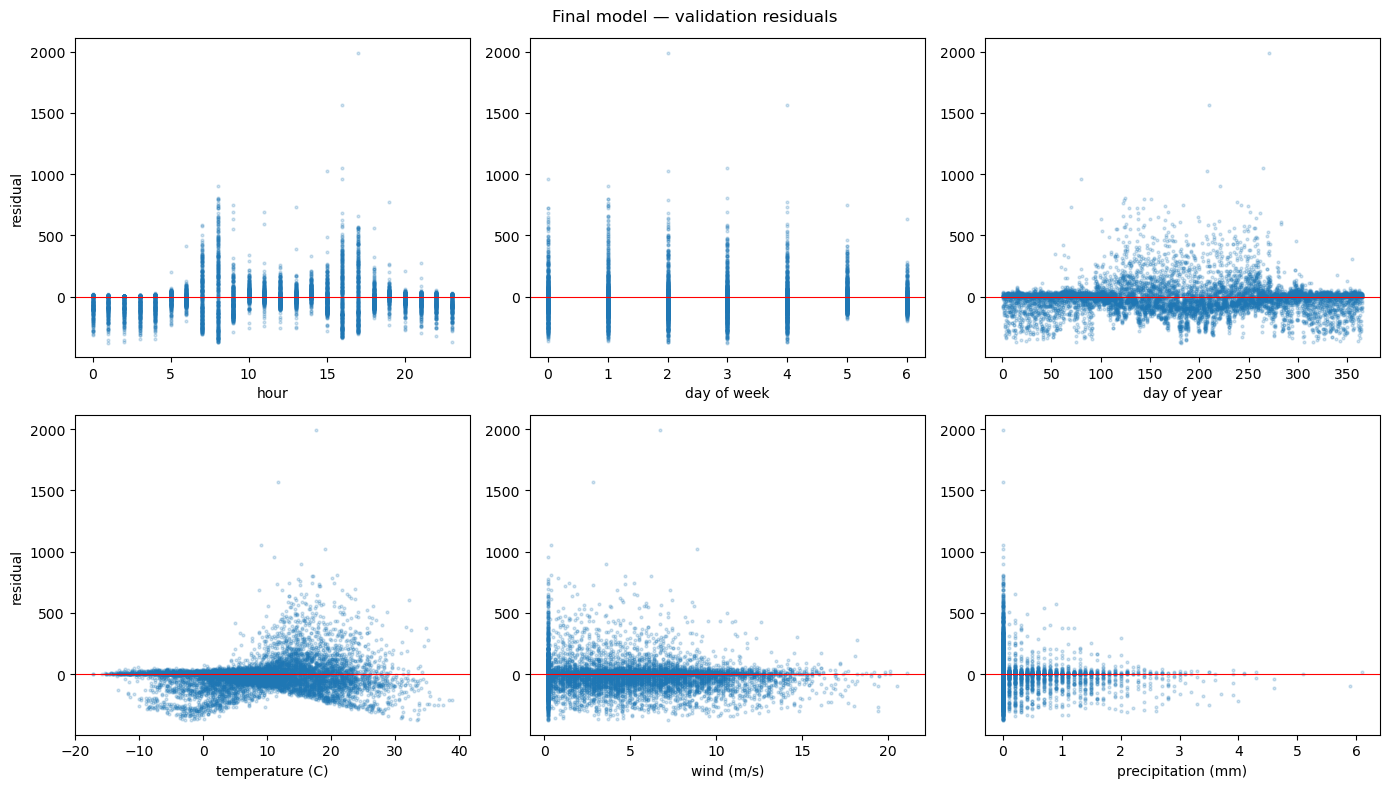

In [35]:
y_va_pred_final = np.maximum((X_va_s @ w_ref).flatten(), 0)
plot_residuals(df_validating, y_va - y_va_pred_final, "Final model — validation residuals")

## Experiments — Individual Feature Extensions
Each experiment adds a single feature group on top of part 3's selected features
to isolate its contribution to validation RMSE.


In [36]:
def fit_and_score(feat_names, lam=0.0, label="model"):
    X_tr = build_X(df_training,   feat_names)
    X_va = build_X(df_validating, feat_names)
    X_te = build_X(df_testing,    feat_names)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    X_te_s = standardize_apply(X_te, mu, sigma)
    w = ridge_reg(X_tr_s, y_tr, lam)
    tr = calculate_RMSE(X_tr_s, w, y_tr)
    va = calculate_RMSE(X_va_s, w, y_va)
    te = calculate_RMSE(X_te_s, w, y_te)
    print(f"{label:35s}  train={tr:.2f}  val={va:.2f}  test={te:.2f}  (n_feat={len(feat_names)})")
    resid = y_va - np.maximum((X_va_s @ w).flatten(), 0)
    return {"label": label, "train": tr, "val": va, "test": te,
            "w": w, "feats": feat_names, "resid_va": resid}


#### Experiment A — Hour-of-day Dummies × Workday

In [37]:
hour_harm_feats    = [f for k in [1,2,3,4,5,6] for f in [f"h_sin{k}", f"h_cos{k}"]]
hour_harm_wd_feats = [f for k in [1,2,3,4,5,6] for f in [f"h_sin{k}_wd", f"h_cos{k}_wd"]]
to_drop = set(hour_harm_feats + hour_harm_wd_feats)

feats_A = [f for f in selected_features_p3 if f not in to_drop] \
          + hour_dummy_feats + hour_dummy_wd_feats

res_A = fit_and_score(feats_A, lam=0.0, label="A: hour dummies x wd")


A: hour dummies x wd                 train=117.69  val=128.29  test=125.03  (n_feat=57)


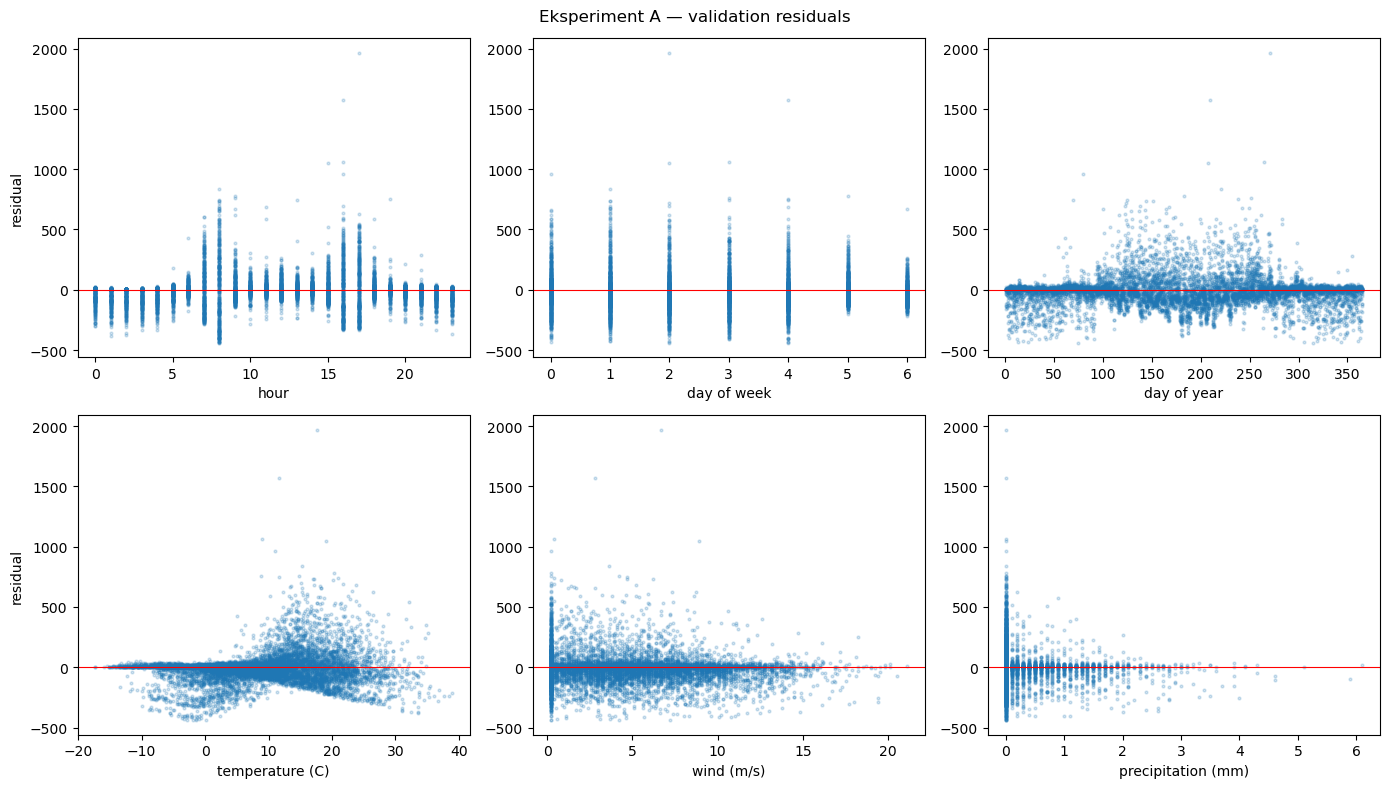

In [38]:
plot_residuals(df_validating, res_A["resid_va"], "Eksperiment A — validation residuals")


#### Experiment B — Hour × Season Interactions

In [39]:
feats_B = list(selected_features_p3) + hour_x_season_feats
res_B = fit_and_score(feats_B, lam=0.0, label="B: hour x season")


B: hour x season                     train=100.48  val=109.49  test=105.88  (n_feat=51)


#### Experiment C — Day-of-week Dummies

In [40]:
feats_C = list(selected_features_p3) + dow_dummy_feats
res_C = fit_and_score(feats_C, lam=0.0, label="C: dow dummies")


C: dow dummies                       train=119.23  val=129.55  test=126.39  (n_feat=41)


#### Experiment D — Hour × Temperature & Precipitation

In [41]:
feats_D = list(selected_features_p3) + hour_x_temp_feats + hour_x_precip_feats
res_D = fit_and_score(feats_D, lam=0.0, label="D: hour x temp + precip")


D: hour x temp + precip              train=98.76  val=107.26  test=103.54  (n_feat=43)


### Comparison of Individual Experiments

model                                  train      val     test    d val
-----------------------------------------------------------------------
Reference (part_3)                    119.46   129.73   126.50    +0.00
A: hour dummies x wd                  117.69   128.29   125.03    -1.44
B: hour x season                      100.48   109.49   105.88   -20.24
C: dow dummies                        119.23   129.55   126.39    -0.18
D: hour x temp + precip                98.76   107.26   103.54   -22.47


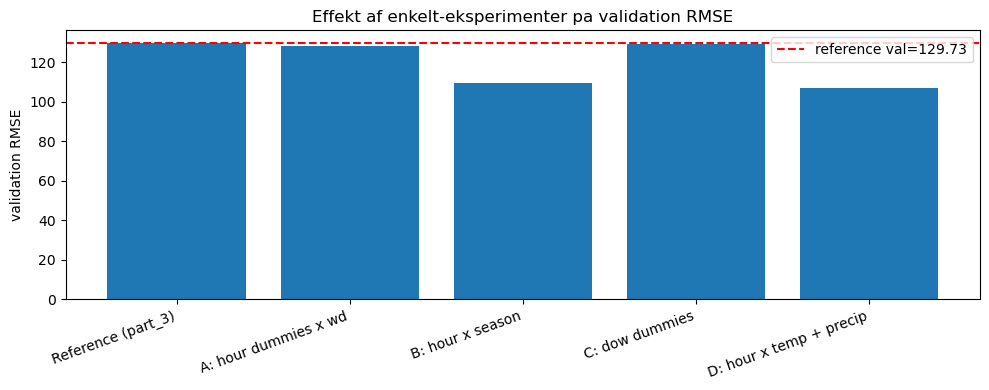

In [42]:
rows = [
    ("Reference (part_3)", ref_train, ref_val, ref_test),
    (res_A["label"], res_A["train"], res_A["val"], res_A["test"]),
    (res_B["label"], res_B["train"], res_B["val"], res_B["test"]),
    (res_C["label"], res_C["train"], res_C["val"], res_C["test"]),
    (res_D["label"], res_D["train"], res_D["val"], res_D["test"]),
]
header = f'{"model":35s} {"train":>8s} {"val":>8s} {"test":>8s} {"d val":>8s}'
print(header)
print("-" * len(header))
for lab, tr, va, te in rows:
    delta = va - ref_val
    print(f"{lab:35s} {tr:8.2f} {va:8.2f} {te:8.2f} {delta:+8.2f}")

labels = [r[0] for r in rows]
vals   = [r[2] for r in rows]
plt.figure(figsize=(10, 4))
plt.bar(range(len(labels)), vals)
plt.axhline(ref_val, color="red", linestyle="--", label=f"reference val={ref_val:.2f}")
plt.xticks(range(len(labels)), labels, rotation=20, ha="right")
plt.ylabel("validation RMSE")
plt.title("Effekt af enkelt-eksperimenter pa validation RMSE")
plt.legend(); plt.tight_layout(); plt.show()


## Combined Model — Forward Selection on Extended Feature Pool
Run forward selection over the union of base groups and all experimental groups.
Forward selection picks the best combination — hour dummies and harmonics overlap
in what they model, so only one will be chosen.


In [43]:
feature_groups_ext = dict(feature_groups)  # copy
feature_groups_ext["hour_dummies"]    = hour_dummy_feats
feature_groups_ext["hour_dummies_wd"] = hour_dummy_wd_feats
feature_groups_ext["hour_x_season"]   = hour_x_season_feats
feature_groups_ext["dow_dummies"]     = dow_dummy_feats
feature_groups_ext["hour_x_temp"]     = hour_x_temp_feats
feature_groups_ext["hour_x_precip"]   = hour_x_precip_feats

selected_groups_ext, selected_features_ext, history_ext = forward_select(
    feature_groups_ext, lam=0.0, verbose=True)
print(f"\nSelected groups (extended): {selected_groups_ext}")


(intercept only)           val RMSE = 264.90
hour_dummies_wd            val RMSE = 197.55
temp                       val RMSE = 151.52
hour_x_temp                val RMSE = 126.15
dayofyear_1                val RMSE = 118.85
temp_x_wd                  val RMSE = 113.73
hour_dummies               val RMSE = 108.94
hour_x_season              val RMSE = 105.96
wind                       val RMSE = 104.48
temp_sq                    val RMSE = 103.23
precip_x_wd                val RMSE = 102.03
hour_x_precip              val RMSE = 101.60
dow_dummies                val RMSE = 101.38
log_precip                 val RMSE = 101.32
wind_x_wd                  val RMSE = 101.28
is_holiday                 val RMSE = 101.25
is_workday                 val RMSE = 101.21
wind_sq                    val RMSE = 101.19
is_raining                 val RMSE = 101.18
precip                     val RMSE = 101.17
hour_6                     val RMSE = 101.17
hour_8                     val RMSE = 101.17
hour_4_8  

### λ-scan on Combined Model

Best lambda: 0, val RMSE: 101.17
OLS (lam=0)  val RMSE: 101.17


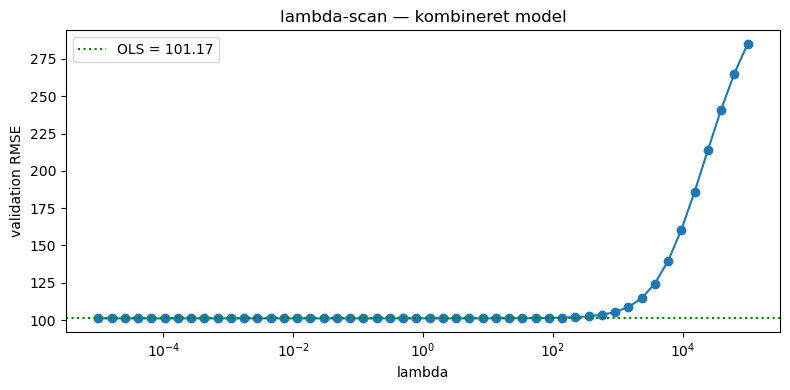

In [44]:
X_tr = build_X(df_training,   selected_features_ext)
X_va = build_X(df_validating, selected_features_ext)
X_te = build_X(df_testing,    selected_features_ext)
X_tr_s, mu_ext, sigma_ext = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu_ext, sigma_ext)
X_te_s = standardize_apply(X_te, mu_ext, sigma_ext)

lambdas = np.concatenate([[0.0], np.logspace(-5, 5, 50)])
val_rmses = [calculate_RMSE(X_va_s, ridge_reg(X_tr_s, y_tr, lam), y_va) for lam in lambdas]
best_idx = int(np.argmin(val_rmses))
best_lam = lambdas[best_idx]
w_final = ridge_reg(X_tr_s, y_tr, best_lam)
print(f"Best lambda: {best_lam:.6g}, val RMSE: {val_rmses[best_idx]:.2f}")
print(f"OLS (lam=0)  val RMSE: {val_rmses[0]:.2f}")

plt.figure(figsize=(8, 4))
plt.semilogx(lambdas[1:], val_rmses[1:], marker="o")
plt.axhline(val_rmses[0], color="green", linestyle=":", label=f"OLS = {val_rmses[0]:.2f}")
if best_lam > 0:
    plt.axvline(best_lam, color="red", linestyle="--", label=f"best lambda = {best_lam:.4g}")
plt.xlabel("lambda"); plt.ylabel("validation RMSE"); plt.legend()
plt.title("lambda-scan — kombineret model")
plt.tight_layout(); plt.show()


### Final Combined Model — Train / Val / Test

In [45]:
w_ext = ridge_reg(X_tr_s, y_tr, best_lam)
ext_train = calculate_RMSE(X_tr_s, w_ext, y_tr)
ext_val   = calculate_RMSE(X_va_s, w_ext, y_va)
ext_test  = calculate_RMSE(X_te_s, w_ext, y_te)

print(f"Reference (part_3)  train={ref_train:.2f}  val={ref_val:.2f}  test={ref_test:.2f}")
print(f"Combined (part_3b)  train={ext_train:.2f}  val={ext_val:.2f}  test={ext_test:.2f}")
print(f"d val: {ext_val - ref_val:+.2f}    d test: {ext_test - ref_test:+.2f}")


Reference (part_3)  train=119.46  val=129.73  test=126.50
Combined (part_3b)  train=92.06  val=101.17  test=97.08
d val: -28.56    d test: -29.42


### Residuals After Combined Model

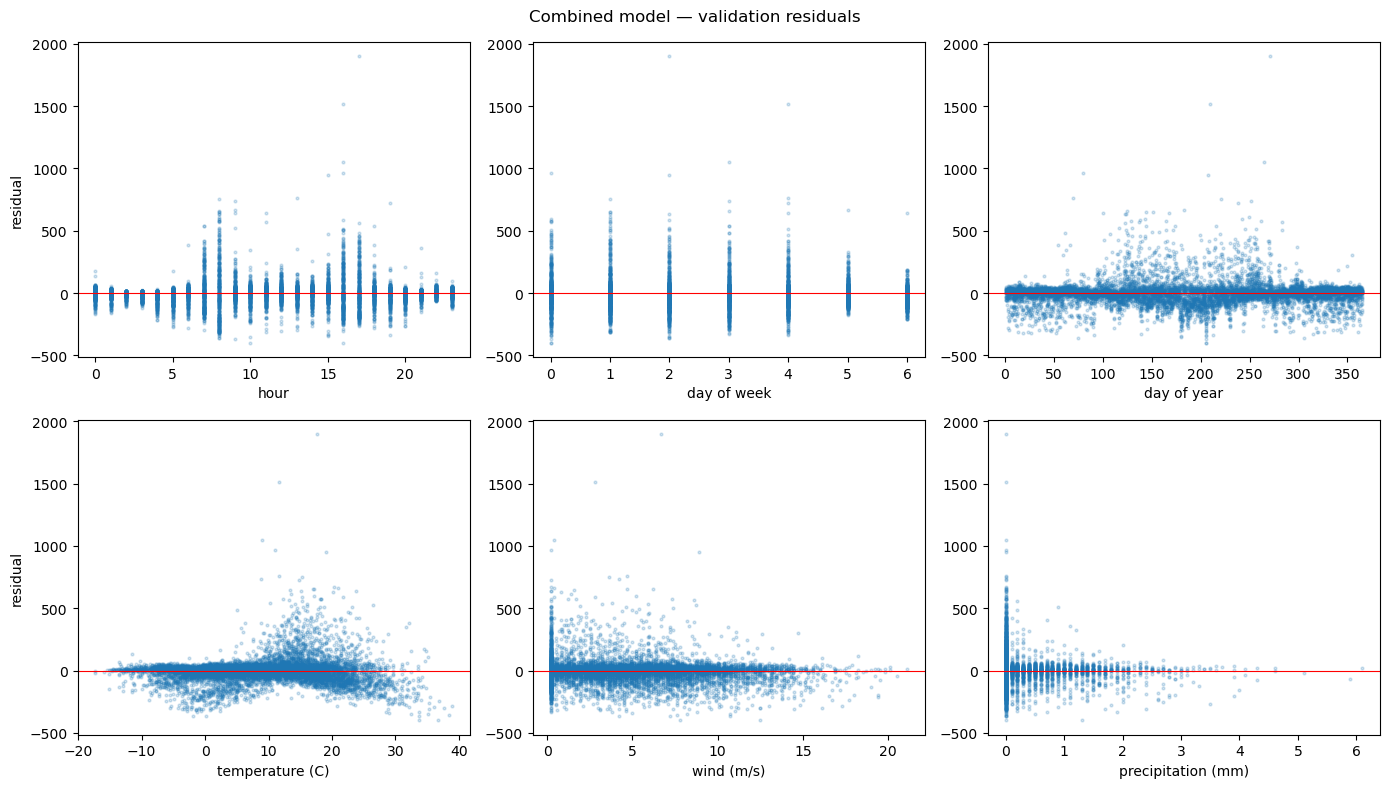

hour 8: ref MAE = 260.05, combined MAE = 193.21
hour 17: ref MAE = 203.28, combined MAE = 138.37


In [46]:
resid_ext_va = y_va - np.maximum((X_va_s @ w_ext).flatten(), 0)
plot_residuals(df_validating, resid_ext_va, "Combined model — validation residuals")

for target_hour in [8, 17]:
    mask = df_validating["datetime"].dt.hour == target_hour
    resid_h_ref = baseline_residuals_va[mask.values]
    resid_h_ext = resid_ext_va[mask.values]
    print(f"hour {target_hour}: ref MAE = {np.mean(np.abs(resid_h_ref)):.2f}, "
          f"combined MAE = {np.mean(np.abs(resid_h_ext)):.2f}")


### Coefficient Interpretation

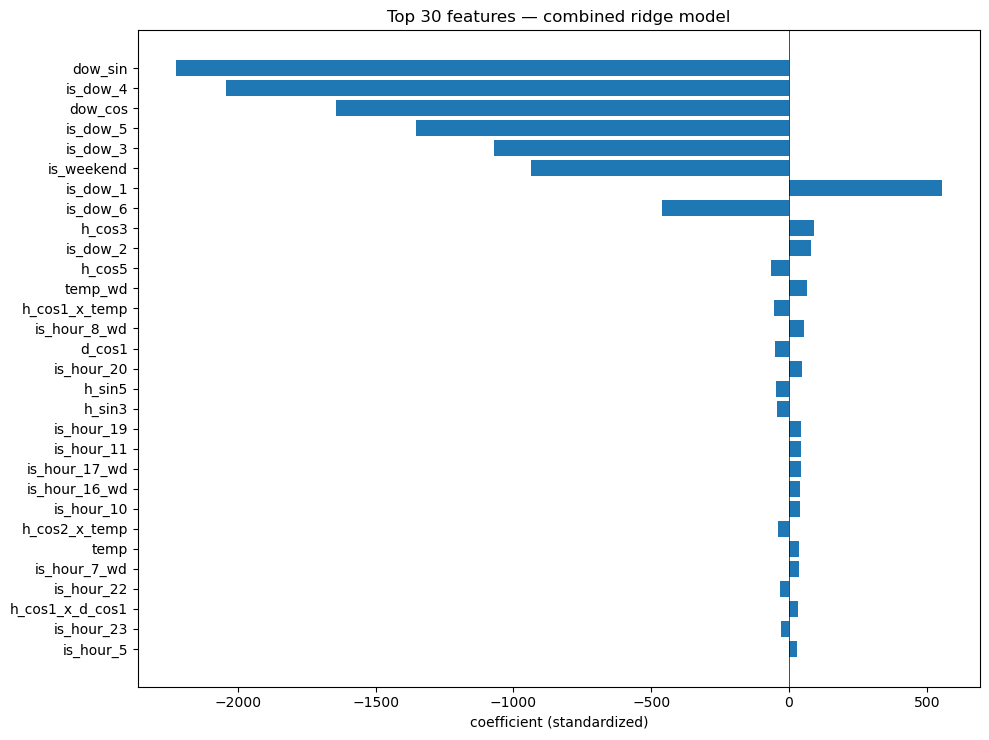

In [47]:
feat_labels_ext = ["intercept"] + selected_features_ext
coefs_ext = w_ext.flatten()
order = np.argsort(np.abs(coefs_ext[1:]))[::-1] + 1  # skip intercept
top_n = min(30, len(order))
order_top = order[:top_n]

plt.figure(figsize=(10, max(4, top_n * 0.25)))
plt.barh(np.array(feat_labels_ext)[order_top][::-1], coefs_ext[order_top][::-1])
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("coefficient (standardized)")
plt.title(f"Top {top_n} features — combined ridge model")
plt.tight_layout(); plt.show()


### Sanity Check — Predicted vs Actual (Test Week)

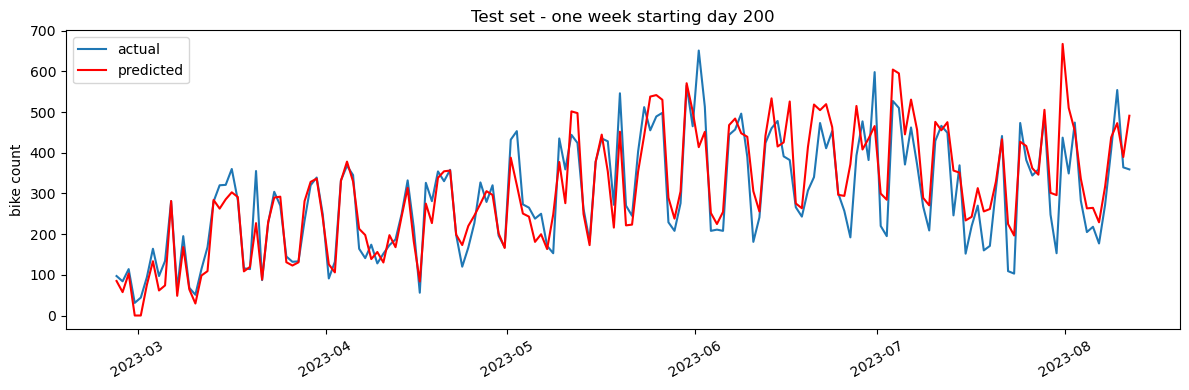

In [48]:
y_te_pred = np.maximum((X_te_s @ w_final).flatten(), 0)

day = 200
plt_hours = 24 * 7
plt.figure(figsize=(12, 4))
plt.plot(df_testing["datetime"].values[24*day : 24*day + plt_hours],
         y_te[24*day : 24*day + plt_hours], label="actual")
plt.plot(df_testing["datetime"].values[24*day : 24*day + plt_hours],
         y_te_pred[24*day : 24*day + plt_hours], color="red", label="predicted")
plt.legend(); plt.xticks(rotation=30); plt.ylabel("bike count")
plt.title(f"Test set - one week starting day {day}")
plt.tight_layout()
plt.show()

## Cross-Station Analysis

### All Stations — Same Station Train & Test

In [49]:
def calculate_and_plot_rmse(station1, station2):
    # ── Local data splits ──────────────────────────────────────────────────────
    df_tr = add_features(
        df_merged[(df_merged["datetime"].dt.year == 2021) &
                  (df_merged["station"] == station1)].copy()
    )
    df_va = add_features(
        df_merged[(df_merged["datetime"].dt.year == 2022) &
                  (df_merged["station"] == station1)].copy()
    )
    df_te = add_features(
        df_merged[(df_merged["datetime"].dt.year == 2023) &
                  (df_merged["station"] == station2)].copy()
    )

    y_tr_loc = df_tr["bike_count"].values
    y_va_loc = df_va["bike_count"].values
    y_te_loc = df_te["bike_count"].values

    # ── Local eval_features that uses local splits ─────────────────────────────
    def eval_features_local(feat_names, lam=0.0):
        X_tr = build_X(df_tr, feat_names)
        X_va = build_X(df_va, feat_names)
        X_tr_s, mu, sigma = standardize_train(X_tr)
        X_va_s = standardize_apply(X_va, mu, sigma)
        try:
            w = ridge_reg(X_tr_s, y_tr_loc, lam)
        except np.linalg.LinAlgError:
            return np.inf
        return calculate_RMSE(X_va_s, w, y_va_loc)

    # ── Forward selection on local data ────────────────────────────────────────
    selected_groups, selected_features = [], []
    remaining = list(feature_groups.keys())
    best_rmse = eval_features_local([])
    history   = [("(intercept only)", best_rmse)]

    while remaining:
        best_g, best_g_rmse = None, best_rmse
        for g in remaining:
            trial = selected_features + feature_groups[g]
            rmse  = eval_features_local(trial)
            if rmse < best_g_rmse:
                best_g_rmse, best_g = rmse, g
        if best_g is None:
            break
        selected_groups.append(best_g)
        selected_features += feature_groups[best_g]
        remaining.remove(best_g)
        best_rmse = best_g_rmse
        history.append((best_g, best_rmse))

    for g, r in history:
        print(f"  {g:25s}  val RMSE = {r:.2f}")
    print(f"  Selected groups: {len(selected_groups)}")

    # ── Build matrices with locally selected features ──────────────────────────
    X_tr = build_X(df_tr, selected_features)
    X_va = build_X(df_va, selected_features)
    X_te = build_X(df_te, selected_features)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    X_te_s = standardize_apply(X_te, mu, sigma)

    # ── λ-scan ─────────────────────────────────────────────────────────────────
    lambdas   = np.concatenate([[0.0], np.logspace(-5, 5, 50)])
    val_rmses = [calculate_RMSE(X_va_s, ridge_reg(X_tr_s, y_tr_loc, lam), y_va_loc)
                 for lam in lambdas]
    best_idx  = int(np.argmin(val_rmses))
    best_lam  = lambdas[best_idx]

    w_best   = ridge_reg(X_tr_s, y_tr_loc, best_lam)
    test_rmse = calculate_RMSE(X_te_s, w_best, y_te_loc)

    label = f"Station {station1}" if station1 == station2 \
            else f"Train: {station1} → Test: {station2}"
    print(f"\n{label}")
    print(f"  best λ={best_lam:.4g}  val RMSE={val_rmses[best_idx]:.2f}  "
          f"test RMSE={test_rmse:.2f}")

    plt.figure(figsize=(8, 4))
    plt.semilogx(lambdas[1:], val_rmses[1:], marker="o", markersize=3)
    plt.axhline(val_rmses[0], color="green", linestyle=":",
                label=f"OLS = {val_rmses[0]:.2f}")
    if best_lam > 0:
        plt.axvline(best_lam, color="red", linestyle="--",
                    label=f"best λ = {best_lam:.4g}")
    plt.xlabel("lambda")
    plt.ylabel("validation RMSE")
    plt.title(label)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"label": label, "val": val_rmses[best_idx], "test": test_rmse}

  (intercept only)           val RMSE = 659.04
  temp_x_wd                  val RMSE = 552.82
  hour_24                    val RMSE = 486.72
  hour_8                     val RMSE = 434.20
  hour12_x_wd                val RMSE = 398.87
  dayofyear_1                val RMSE = 373.23
  hour_4_8                   val RMSE = 348.66
  hour4_x_wd                 val RMSE = 338.75
  hour24_x_wd                val RMSE = 332.17
  hour_12                    val RMSE = 329.26
  hour8_x_wd                 val RMSE = 325.63
  wind                       val RMSE = 322.95
  precip                     val RMSE = 321.12
  hour4_8_x_wd               val RMSE = 319.93
  hour_4                     val RMSE = 318.61
  temp                       val RMSE = 317.75
  hour6_x_wd                 val RMSE = 317.10
  precip_x_wd                val RMSE = 317.03
  hour_6                     val RMSE = 316.98
  Selected groups: 18

Station Dronning_Louises_Bro
  best λ=0  val RMSE=316.98  test RMSE=316.24


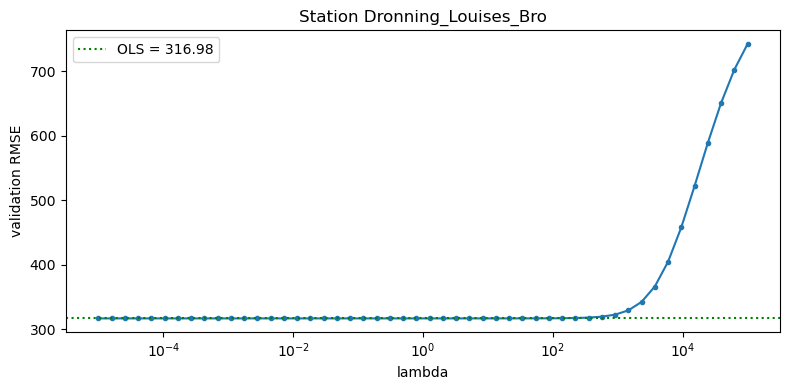

  (intercept only)           val RMSE = 370.84
  temp_x_wd                  val RMSE = 310.97
  hour_24                    val RMSE = 273.93
  hour_8                     val RMSE = 244.82
  hour12_x_wd                val RMSE = 225.26
  dayofyear_1                val RMSE = 210.91
  hour_4_8                   val RMSE = 197.35
  hour4_x_wd                 val RMSE = 191.41
  hour24_x_wd                val RMSE = 187.70
  hour_12                    val RMSE = 186.19
  hour8_x_wd                 val RMSE = 184.05
  wind                       val RMSE = 182.60
  precip                     val RMSE = 181.64
  hour4_8_x_wd               val RMSE = 180.89
  hour_4                     val RMSE = 180.19
  temp                       val RMSE = 179.68
  hour_6                     val RMSE = 179.35
  precip_x_wd                val RMSE = 179.32
  dayofyear_2                val RMSE = 179.31
  hour6_x_wd                 val RMSE = 179.30
  Selected groups: 19

Station Torvegade
  best λ=0  val RMS

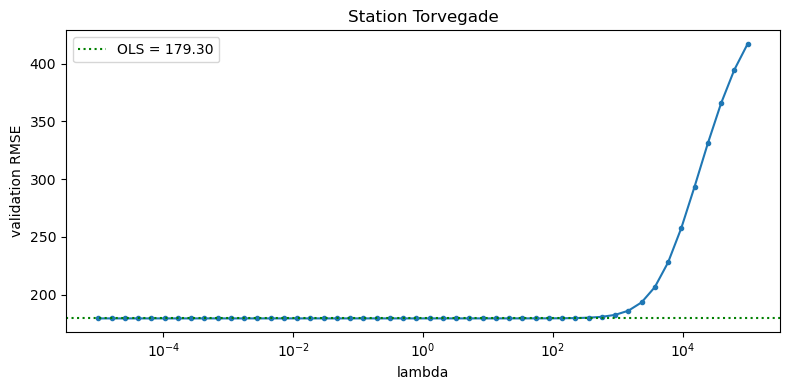

  (intercept only)           val RMSE = 513.28
  temp_x_wd                  val RMSE = 430.02
  hour_24                    val RMSE = 378.54
  hour_8                     val RMSE = 337.52
  hour12_x_wd                val RMSE = 309.50
  dayofyear_1                val RMSE = 289.01
  hour_4_8                   val RMSE = 270.50
  hour4_x_wd                 val RMSE = 262.62
  hour24_x_wd                val RMSE = 257.41
  hour_12                    val RMSE = 255.23
  hour8_x_wd                 val RMSE = 252.34
  wind                       val RMSE = 250.18
  precip                     val RMSE = 248.70
  hour4_8_x_wd               val RMSE = 247.79
  hour_4                     val RMSE = 246.82
  temp                       val RMSE = 246.24
  hour6_x_wd                 val RMSE = 245.79
  precip_x_wd                val RMSE = 245.74
  hour_6                     val RMSE = 245.71
  Selected groups: 18

Station Noerrebrogade
  best λ=0  val RMSE=245.71  test RMSE=248.00


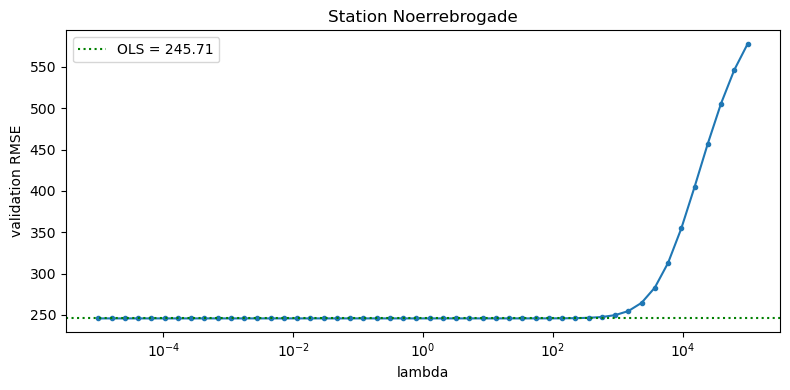

  (intercept only)           val RMSE = 301.62
  temp_x_wd                  val RMSE = 254.24
  hour_24                    val RMSE = 225.33
  hour_8                     val RMSE = 201.57
  hour12_x_wd                val RMSE = 185.31
  dayofyear_1                val RMSE = 174.03
  hour_4_8                   val RMSE = 163.29
  hour4_x_wd                 val RMSE = 158.73
  hour24_x_wd                val RMSE = 155.89
  hour_12                    val RMSE = 154.72
  hour8_x_wd                 val RMSE = 152.89
  wind                       val RMSE = 151.71
  precip                     val RMSE = 150.84
  hour4_8_x_wd               val RMSE = 150.28
  hour_4                     val RMSE = 149.70
  temp                       val RMSE = 149.36
  hour_6                     val RMSE = 149.08
  precip_x_wd                val RMSE = 149.04
  wind_sq                    val RMSE = 149.04
  Selected groups: 18

Station H_C_Andersens_Boulevard
  best λ=21.21  val RMSE=149.04  test RMSE=142.44


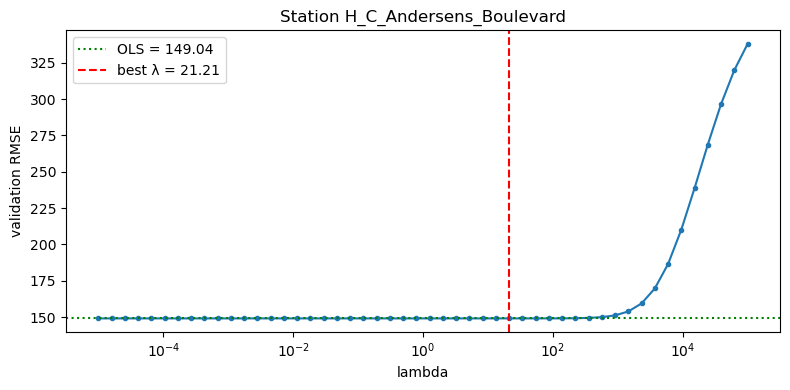

  (intercept only)           val RMSE = 264.90
  temp_x_wd                  val RMSE = 222.42
  hour_24                    val RMSE = 196.28
  hour_8                     val RMSE = 175.69
  hour12_x_wd                val RMSE = 161.85
  dayofyear_1                val RMSE = 151.81
  hour_4_8                   val RMSE = 142.30
  hour4_x_wd                 val RMSE = 138.47
  hour24_x_wd                val RMSE = 135.80
  wind                       val RMSE = 134.71
  hour_12                    val RMSE = 133.63
  hour8_x_wd                 val RMSE = 132.15
  precip                     val RMSE = 131.43
  hour4_8_x_wd               val RMSE = 130.92
  hour_4                     val RMSE = 130.41
  temp                       val RMSE = 130.11
  hour_6                     val RMSE = 129.92
  hour6_x_wd                 val RMSE = 129.90
  precip_x_wd                val RMSE = 129.89
  is_weekend                 val RMSE = 129.88
  wind_x_wd                  val RMSE = 129.80
  is_holiday 

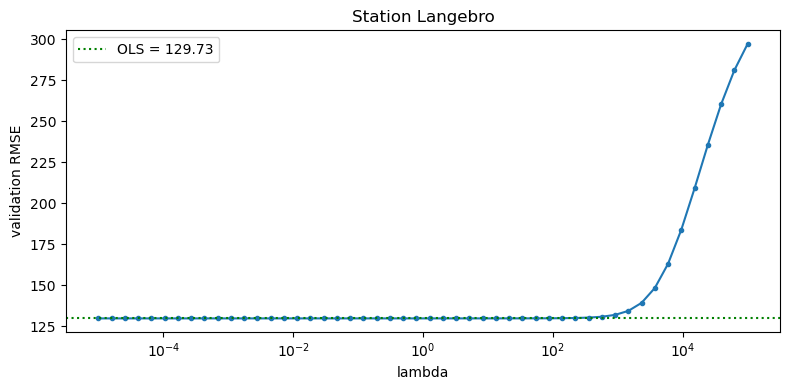

  (intercept only)           val RMSE = 230.94
  temp_x_wd                  val RMSE = 195.26
  hour_24                    val RMSE = 173.39
  hour_8                     val RMSE = 156.03
  hour12_x_wd                val RMSE = 144.42
  dayofyear_1                val RMSE = 135.95
  hour_4_8                   val RMSE = 128.46
  hour4_x_wd                 val RMSE = 125.40
  hour24_x_wd                val RMSE = 123.28
  hour_12                    val RMSE = 122.42
  hour8_x_wd                 val RMSE = 121.16
  wind                       val RMSE = 120.35
  precip                     val RMSE = 119.79
  hour4_8_x_wd               val RMSE = 119.43
  hour_4                     val RMSE = 119.02
  temp                       val RMSE = 118.80
  hour_6                     val RMSE = 118.60
  dayofyear_2                val RMSE = 118.57
  precip_x_wd                val RMSE = 118.56
  hour6_x_wd                 val RMSE = 118.54
  wind_sq                    val RMSE = 118.54
  Selected gr

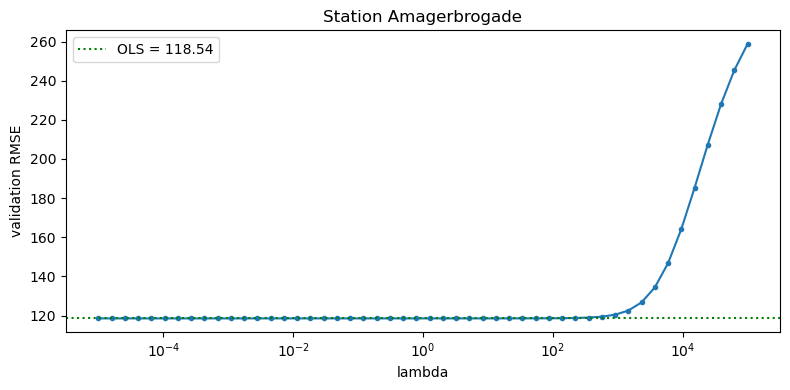

In [50]:
stations = ["Dronning_Louises_Bro","Torvegade","Noerrebrogade","H_C_Andersens_Boulevard","Langebro","Amagerbrogade"]
for station in stations:
    calculate_and_plot_rmse(station,station)

### Cross-Station — Train on One, Test on Another

  (intercept only)           val RMSE = 659.04
  temp_x_wd                  val RMSE = 552.82
  hour_24                    val RMSE = 486.72
  hour_8                     val RMSE = 434.20
  hour12_x_wd                val RMSE = 398.87
  dayofyear_1                val RMSE = 373.23
  hour_4_8                   val RMSE = 348.66
  hour4_x_wd                 val RMSE = 338.75
  hour24_x_wd                val RMSE = 332.17
  hour_12                    val RMSE = 329.26
  hour8_x_wd                 val RMSE = 325.63
  wind                       val RMSE = 322.95
  precip                     val RMSE = 321.12
  hour4_8_x_wd               val RMSE = 319.93
  hour_4                     val RMSE = 318.61
  temp                       val RMSE = 317.75
  hour6_x_wd                 val RMSE = 317.10
  precip_x_wd                val RMSE = 317.03
  hour_6                     val RMSE = 316.98
  Selected groups: 18

Station Dronning_Louises_Bro
  best λ=0  val RMSE=316.98  test RMSE=316.24


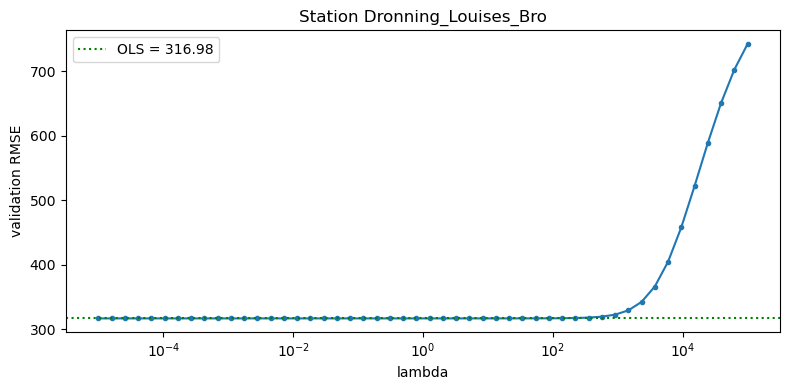

  (intercept only)           val RMSE = 659.04
  temp_x_wd                  val RMSE = 552.82
  hour_24                    val RMSE = 486.72
  hour_8                     val RMSE = 434.20
  hour12_x_wd                val RMSE = 398.87
  dayofyear_1                val RMSE = 373.23
  hour_4_8                   val RMSE = 348.66
  hour4_x_wd                 val RMSE = 338.75
  hour24_x_wd                val RMSE = 332.17
  hour_12                    val RMSE = 329.26
  hour8_x_wd                 val RMSE = 325.63
  wind                       val RMSE = 322.95
  precip                     val RMSE = 321.12
  hour4_8_x_wd               val RMSE = 319.93
  hour_4                     val RMSE = 318.61
  temp                       val RMSE = 317.75
  hour6_x_wd                 val RMSE = 317.10
  precip_x_wd                val RMSE = 317.03
  hour_6                     val RMSE = 316.98
  Selected groups: 18

Train: Dronning_Louises_Bro → Test: Torvegade
  best λ=0  val RMSE=316.98  test RMSE

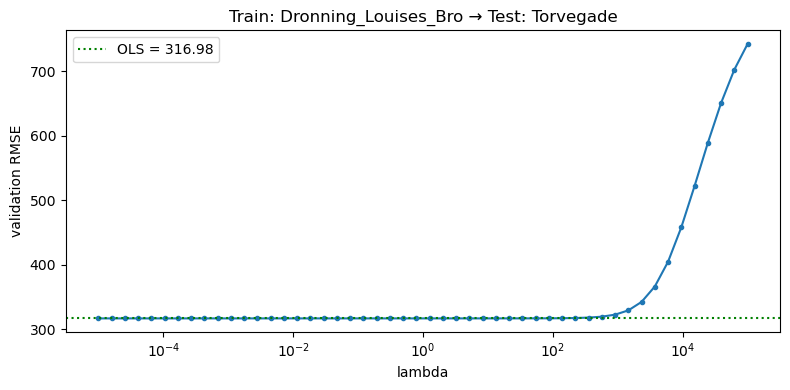

  (intercept only)           val RMSE = 659.04
  temp_x_wd                  val RMSE = 552.82
  hour_24                    val RMSE = 486.72
  hour_8                     val RMSE = 434.20
  hour12_x_wd                val RMSE = 398.87
  dayofyear_1                val RMSE = 373.23
  hour_4_8                   val RMSE = 348.66
  hour4_x_wd                 val RMSE = 338.75
  hour24_x_wd                val RMSE = 332.17
  hour_12                    val RMSE = 329.26
  hour8_x_wd                 val RMSE = 325.63
  wind                       val RMSE = 322.95
  precip                     val RMSE = 321.12
  hour4_8_x_wd               val RMSE = 319.93
  hour_4                     val RMSE = 318.61
  temp                       val RMSE = 317.75
  hour6_x_wd                 val RMSE = 317.10
  precip_x_wd                val RMSE = 317.03
  hour_6                     val RMSE = 316.98
  Selected groups: 18

Train: Dronning_Louises_Bro → Test: Noerrebrogade
  best λ=0  val RMSE=316.98  test 

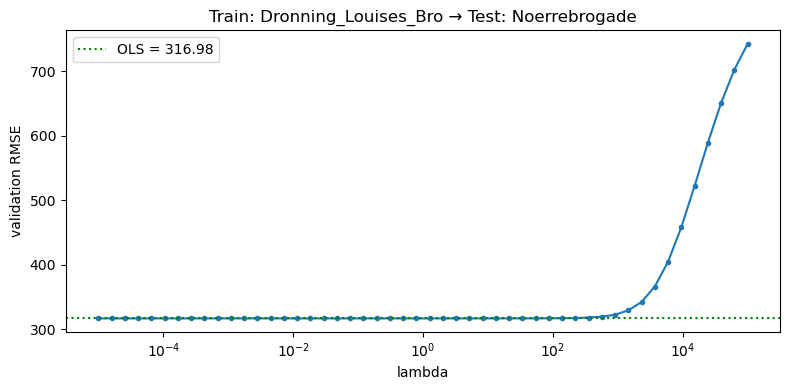

  (intercept only)           val RMSE = 659.04
  temp_x_wd                  val RMSE = 552.82
  hour_24                    val RMSE = 486.72
  hour_8                     val RMSE = 434.20
  hour12_x_wd                val RMSE = 398.87
  dayofyear_1                val RMSE = 373.23
  hour_4_8                   val RMSE = 348.66
  hour4_x_wd                 val RMSE = 338.75
  hour24_x_wd                val RMSE = 332.17
  hour_12                    val RMSE = 329.26
  hour8_x_wd                 val RMSE = 325.63
  wind                       val RMSE = 322.95
  precip                     val RMSE = 321.12
  hour4_8_x_wd               val RMSE = 319.93
  hour_4                     val RMSE = 318.61
  temp                       val RMSE = 317.75
  hour6_x_wd                 val RMSE = 317.10
  precip_x_wd                val RMSE = 317.03
  hour_6                     val RMSE = 316.98
  Selected groups: 18

Train: Dronning_Louises_Bro → Test: H_C_Andersens_Boulevard
  best λ=0  val RMSE=316

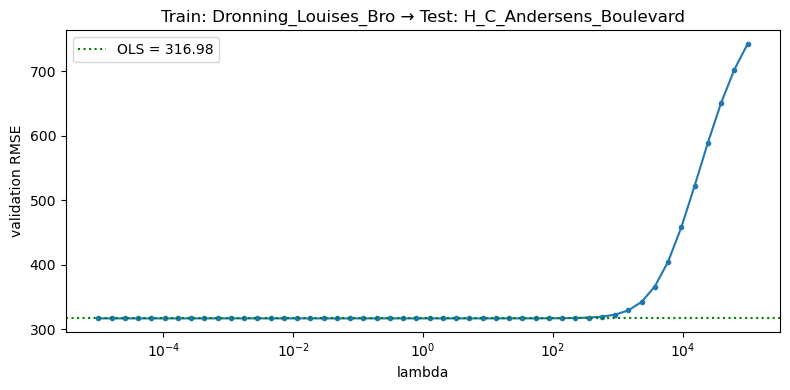

  (intercept only)           val RMSE = 659.04
  temp_x_wd                  val RMSE = 552.82
  hour_24                    val RMSE = 486.72
  hour_8                     val RMSE = 434.20
  hour12_x_wd                val RMSE = 398.87
  dayofyear_1                val RMSE = 373.23
  hour_4_8                   val RMSE = 348.66
  hour4_x_wd                 val RMSE = 338.75
  hour24_x_wd                val RMSE = 332.17
  hour_12                    val RMSE = 329.26
  hour8_x_wd                 val RMSE = 325.63
  wind                       val RMSE = 322.95
  precip                     val RMSE = 321.12
  hour4_8_x_wd               val RMSE = 319.93
  hour_4                     val RMSE = 318.61
  temp                       val RMSE = 317.75
  hour6_x_wd                 val RMSE = 317.10
  precip_x_wd                val RMSE = 317.03
  hour_6                     val RMSE = 316.98
  Selected groups: 18

Train: Dronning_Louises_Bro → Test: Langebro
  best λ=0  val RMSE=316.98  test RMSE=

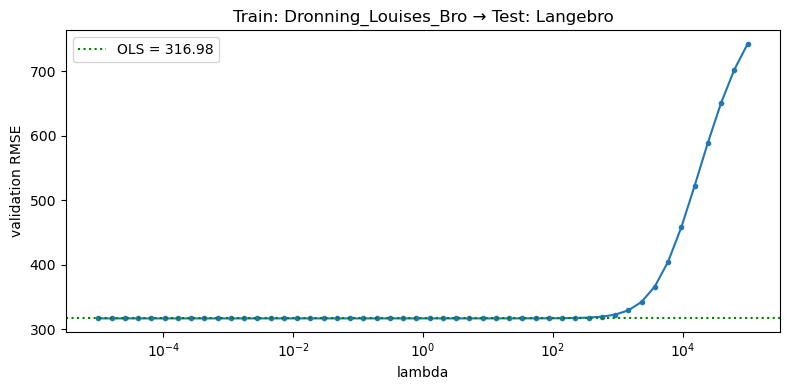

  (intercept only)           val RMSE = 659.04
  temp_x_wd                  val RMSE = 552.82
  hour_24                    val RMSE = 486.72
  hour_8                     val RMSE = 434.20
  hour12_x_wd                val RMSE = 398.87
  dayofyear_1                val RMSE = 373.23
  hour_4_8                   val RMSE = 348.66
  hour4_x_wd                 val RMSE = 338.75
  hour24_x_wd                val RMSE = 332.17
  hour_12                    val RMSE = 329.26
  hour8_x_wd                 val RMSE = 325.63
  wind                       val RMSE = 322.95
  precip                     val RMSE = 321.12
  hour4_8_x_wd               val RMSE = 319.93
  hour_4                     val RMSE = 318.61
  temp                       val RMSE = 317.75
  hour6_x_wd                 val RMSE = 317.10
  precip_x_wd                val RMSE = 317.03
  hour_6                     val RMSE = 316.98
  Selected groups: 18

Train: Dronning_Louises_Bro → Test: Amagerbrogade
  best λ=0  val RMSE=316.98  test 

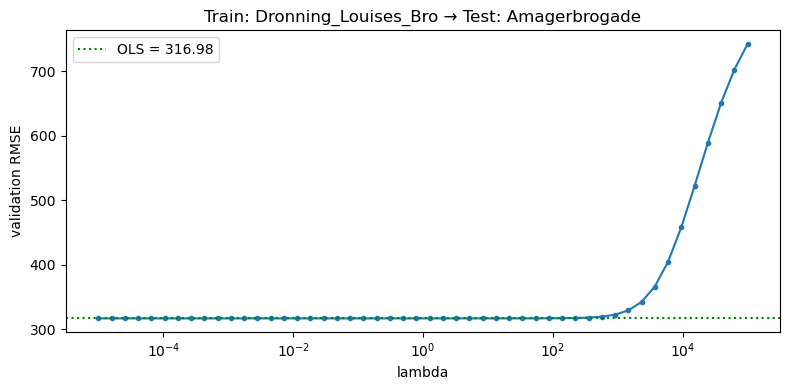

  (intercept only)           val RMSE = 370.84
  temp_x_wd                  val RMSE = 310.97
  hour_24                    val RMSE = 273.93
  hour_8                     val RMSE = 244.82
  hour12_x_wd                val RMSE = 225.26
  dayofyear_1                val RMSE = 210.91
  hour_4_8                   val RMSE = 197.35
  hour4_x_wd                 val RMSE = 191.41
  hour24_x_wd                val RMSE = 187.70
  hour_12                    val RMSE = 186.19
  hour8_x_wd                 val RMSE = 184.05
  wind                       val RMSE = 182.60
  precip                     val RMSE = 181.64
  hour4_8_x_wd               val RMSE = 180.89
  hour_4                     val RMSE = 180.19
  temp                       val RMSE = 179.68
  hour_6                     val RMSE = 179.35
  precip_x_wd                val RMSE = 179.32
  dayofyear_2                val RMSE = 179.31
  hour6_x_wd                 val RMSE = 179.30
  Selected groups: 19

Train: Torvegade → Test: Dronning_Lou

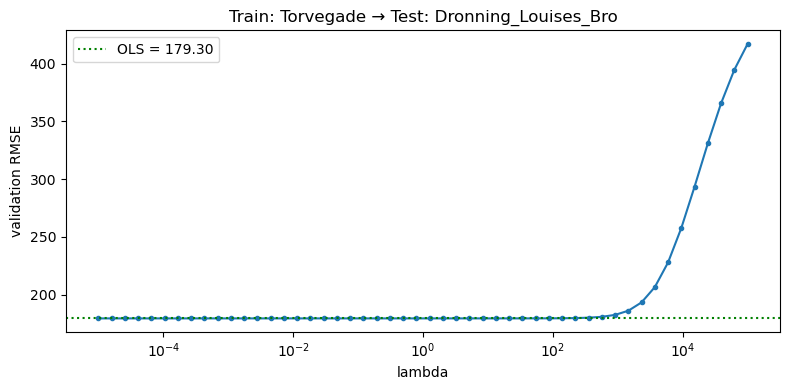

  (intercept only)           val RMSE = 370.84
  temp_x_wd                  val RMSE = 310.97
  hour_24                    val RMSE = 273.93
  hour_8                     val RMSE = 244.82
  hour12_x_wd                val RMSE = 225.26
  dayofyear_1                val RMSE = 210.91
  hour_4_8                   val RMSE = 197.35
  hour4_x_wd                 val RMSE = 191.41
  hour24_x_wd                val RMSE = 187.70
  hour_12                    val RMSE = 186.19
  hour8_x_wd                 val RMSE = 184.05
  wind                       val RMSE = 182.60
  precip                     val RMSE = 181.64
  hour4_8_x_wd               val RMSE = 180.89
  hour_4                     val RMSE = 180.19
  temp                       val RMSE = 179.68
  hour_6                     val RMSE = 179.35
  precip_x_wd                val RMSE = 179.32
  dayofyear_2                val RMSE = 179.31
  hour6_x_wd                 val RMSE = 179.30
  Selected groups: 19

Station Torvegade
  best λ=0  val RMS

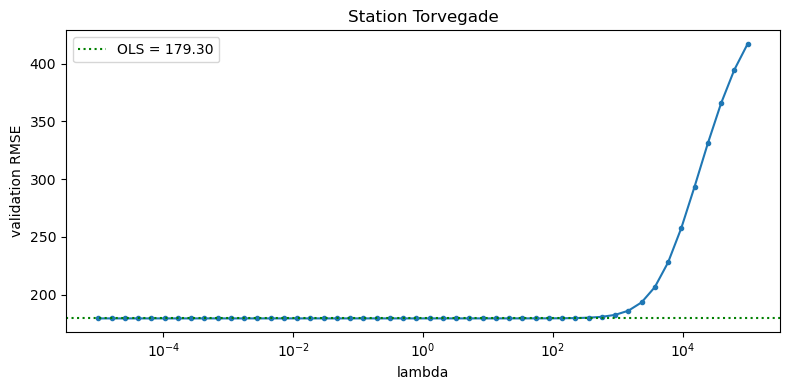

  (intercept only)           val RMSE = 370.84
  temp_x_wd                  val RMSE = 310.97
  hour_24                    val RMSE = 273.93
  hour_8                     val RMSE = 244.82
  hour12_x_wd                val RMSE = 225.26
  dayofyear_1                val RMSE = 210.91
  hour_4_8                   val RMSE = 197.35
  hour4_x_wd                 val RMSE = 191.41
  hour24_x_wd                val RMSE = 187.70
  hour_12                    val RMSE = 186.19
  hour8_x_wd                 val RMSE = 184.05
  wind                       val RMSE = 182.60
  precip                     val RMSE = 181.64
  hour4_8_x_wd               val RMSE = 180.89
  hour_4                     val RMSE = 180.19
  temp                       val RMSE = 179.68
  hour_6                     val RMSE = 179.35
  precip_x_wd                val RMSE = 179.32
  dayofyear_2                val RMSE = 179.31
  hour6_x_wd                 val RMSE = 179.30
  Selected groups: 19

Train: Torvegade → Test: Noerrebrogad

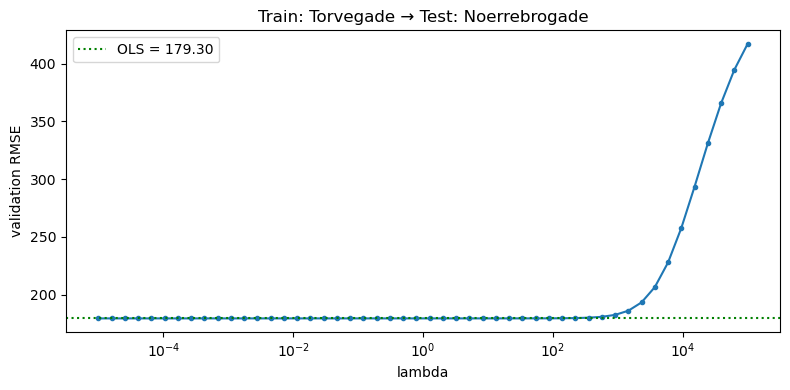

  (intercept only)           val RMSE = 370.84
  temp_x_wd                  val RMSE = 310.97
  hour_24                    val RMSE = 273.93
  hour_8                     val RMSE = 244.82
  hour12_x_wd                val RMSE = 225.26
  dayofyear_1                val RMSE = 210.91
  hour_4_8                   val RMSE = 197.35
  hour4_x_wd                 val RMSE = 191.41
  hour24_x_wd                val RMSE = 187.70
  hour_12                    val RMSE = 186.19
  hour8_x_wd                 val RMSE = 184.05
  wind                       val RMSE = 182.60
  precip                     val RMSE = 181.64
  hour4_8_x_wd               val RMSE = 180.89
  hour_4                     val RMSE = 180.19
  temp                       val RMSE = 179.68
  hour_6                     val RMSE = 179.35
  precip_x_wd                val RMSE = 179.32
  dayofyear_2                val RMSE = 179.31
  hour6_x_wd                 val RMSE = 179.30
  Selected groups: 19

Train: Torvegade → Test: H_C_Andersen

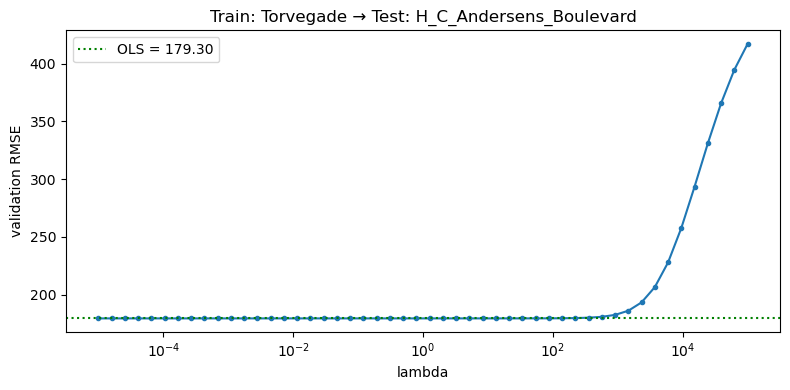

  (intercept only)           val RMSE = 370.84
  temp_x_wd                  val RMSE = 310.97
  hour_24                    val RMSE = 273.93
  hour_8                     val RMSE = 244.82
  hour12_x_wd                val RMSE = 225.26
  dayofyear_1                val RMSE = 210.91
  hour_4_8                   val RMSE = 197.35
  hour4_x_wd                 val RMSE = 191.41
  hour24_x_wd                val RMSE = 187.70
  hour_12                    val RMSE = 186.19
  hour8_x_wd                 val RMSE = 184.05
  wind                       val RMSE = 182.60
  precip                     val RMSE = 181.64
  hour4_8_x_wd               val RMSE = 180.89
  hour_4                     val RMSE = 180.19
  temp                       val RMSE = 179.68
  hour_6                     val RMSE = 179.35
  precip_x_wd                val RMSE = 179.32
  dayofyear_2                val RMSE = 179.31
  hour6_x_wd                 val RMSE = 179.30
  Selected groups: 19

Train: Torvegade → Test: Langebro
  b

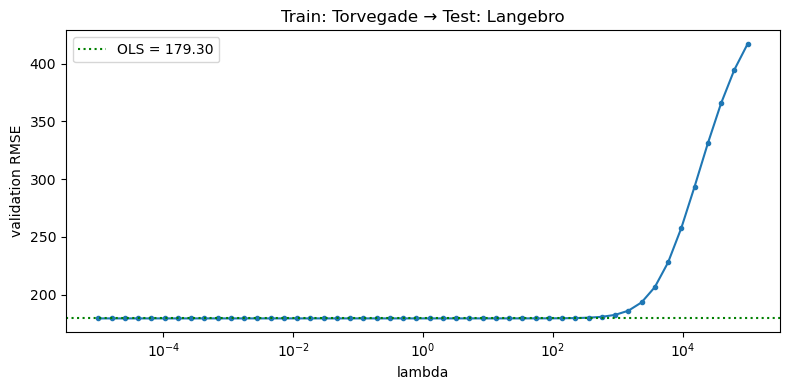

  (intercept only)           val RMSE = 370.84
  temp_x_wd                  val RMSE = 310.97
  hour_24                    val RMSE = 273.93
  hour_8                     val RMSE = 244.82
  hour12_x_wd                val RMSE = 225.26
  dayofyear_1                val RMSE = 210.91
  hour_4_8                   val RMSE = 197.35
  hour4_x_wd                 val RMSE = 191.41
  hour24_x_wd                val RMSE = 187.70
  hour_12                    val RMSE = 186.19
  hour8_x_wd                 val RMSE = 184.05
  wind                       val RMSE = 182.60
  precip                     val RMSE = 181.64
  hour4_8_x_wd               val RMSE = 180.89
  hour_4                     val RMSE = 180.19
  temp                       val RMSE = 179.68
  hour_6                     val RMSE = 179.35
  precip_x_wd                val RMSE = 179.32
  dayofyear_2                val RMSE = 179.31
  hour6_x_wd                 val RMSE = 179.30
  Selected groups: 19

Train: Torvegade → Test: Amagerbrogad

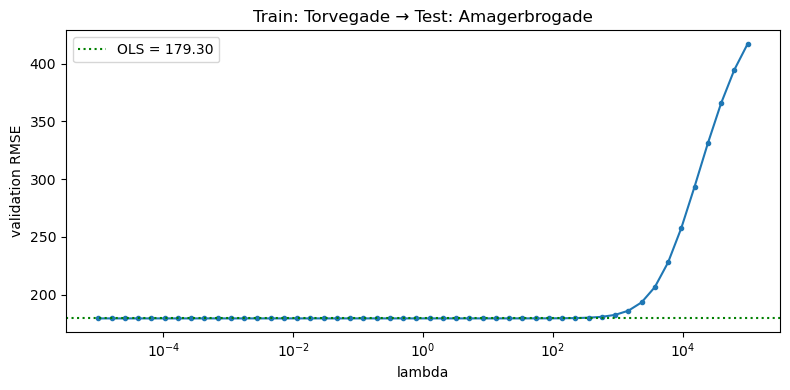

  (intercept only)           val RMSE = 513.28
  temp_x_wd                  val RMSE = 430.02
  hour_24                    val RMSE = 378.54
  hour_8                     val RMSE = 337.52
  hour12_x_wd                val RMSE = 309.50
  dayofyear_1                val RMSE = 289.01
  hour_4_8                   val RMSE = 270.50
  hour4_x_wd                 val RMSE = 262.62
  hour24_x_wd                val RMSE = 257.41
  hour_12                    val RMSE = 255.23
  hour8_x_wd                 val RMSE = 252.34
  wind                       val RMSE = 250.18
  precip                     val RMSE = 248.70
  hour4_8_x_wd               val RMSE = 247.79
  hour_4                     val RMSE = 246.82
  temp                       val RMSE = 246.24
  hour6_x_wd                 val RMSE = 245.79
  precip_x_wd                val RMSE = 245.74
  hour_6                     val RMSE = 245.71
  Selected groups: 18

Train: Noerrebrogade → Test: Dronning_Louises_Bro
  best λ=0  val RMSE=245.71  test 

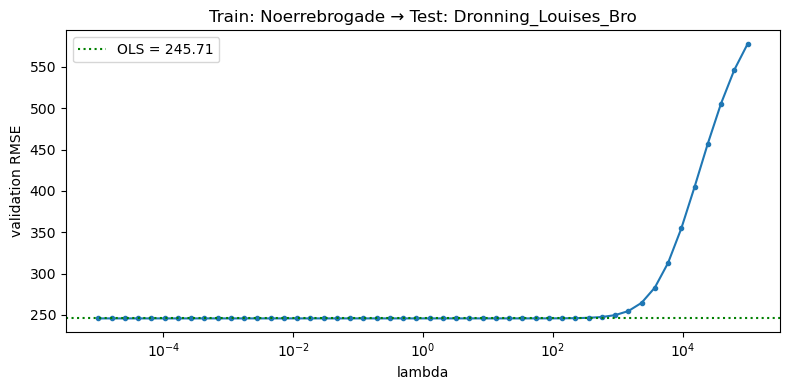

  (intercept only)           val RMSE = 513.28
  temp_x_wd                  val RMSE = 430.02
  hour_24                    val RMSE = 378.54
  hour_8                     val RMSE = 337.52
  hour12_x_wd                val RMSE = 309.50
  dayofyear_1                val RMSE = 289.01
  hour_4_8                   val RMSE = 270.50
  hour4_x_wd                 val RMSE = 262.62
  hour24_x_wd                val RMSE = 257.41
  hour_12                    val RMSE = 255.23
  hour8_x_wd                 val RMSE = 252.34
  wind                       val RMSE = 250.18
  precip                     val RMSE = 248.70
  hour4_8_x_wd               val RMSE = 247.79
  hour_4                     val RMSE = 246.82
  temp                       val RMSE = 246.24
  hour6_x_wd                 val RMSE = 245.79
  precip_x_wd                val RMSE = 245.74
  hour_6                     val RMSE = 245.71
  Selected groups: 18

Train: Noerrebrogade → Test: Torvegade
  best λ=0  val RMSE=245.71  test RMSE=218.28

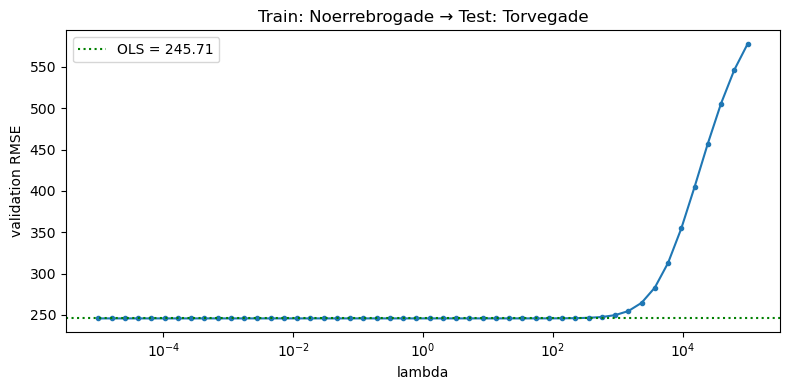

  (intercept only)           val RMSE = 513.28
  temp_x_wd                  val RMSE = 430.02
  hour_24                    val RMSE = 378.54
  hour_8                     val RMSE = 337.52
  hour12_x_wd                val RMSE = 309.50
  dayofyear_1                val RMSE = 289.01
  hour_4_8                   val RMSE = 270.50
  hour4_x_wd                 val RMSE = 262.62
  hour24_x_wd                val RMSE = 257.41
  hour_12                    val RMSE = 255.23
  hour8_x_wd                 val RMSE = 252.34
  wind                       val RMSE = 250.18
  precip                     val RMSE = 248.70
  hour4_8_x_wd               val RMSE = 247.79
  hour_4                     val RMSE = 246.82
  temp                       val RMSE = 246.24
  hour6_x_wd                 val RMSE = 245.79
  precip_x_wd                val RMSE = 245.74
  hour_6                     val RMSE = 245.71
  Selected groups: 18

Station Noerrebrogade
  best λ=0  val RMSE=245.71  test RMSE=248.00


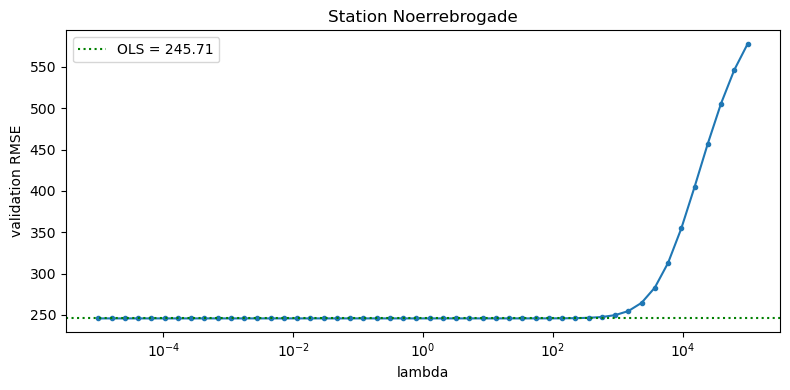

  (intercept only)           val RMSE = 513.28
  temp_x_wd                  val RMSE = 430.02
  hour_24                    val RMSE = 378.54
  hour_8                     val RMSE = 337.52
  hour12_x_wd                val RMSE = 309.50
  dayofyear_1                val RMSE = 289.01
  hour_4_8                   val RMSE = 270.50
  hour4_x_wd                 val RMSE = 262.62
  hour24_x_wd                val RMSE = 257.41
  hour_12                    val RMSE = 255.23
  hour8_x_wd                 val RMSE = 252.34
  wind                       val RMSE = 250.18
  precip                     val RMSE = 248.70
  hour4_8_x_wd               val RMSE = 247.79
  hour_4                     val RMSE = 246.82
  temp                       val RMSE = 246.24
  hour6_x_wd                 val RMSE = 245.79
  precip_x_wd                val RMSE = 245.74
  hour_6                     val RMSE = 245.71
  Selected groups: 18

Train: Noerrebrogade → Test: H_C_Andersens_Boulevard
  best λ=0  val RMSE=245.71  te

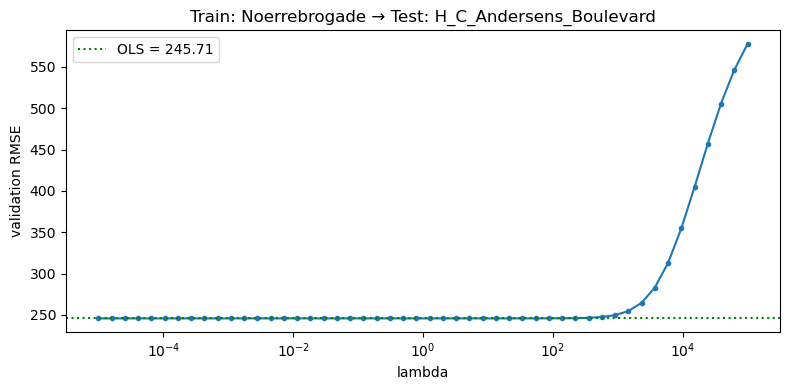

  (intercept only)           val RMSE = 513.28
  temp_x_wd                  val RMSE = 430.02
  hour_24                    val RMSE = 378.54
  hour_8                     val RMSE = 337.52
  hour12_x_wd                val RMSE = 309.50
  dayofyear_1                val RMSE = 289.01
  hour_4_8                   val RMSE = 270.50
  hour4_x_wd                 val RMSE = 262.62
  hour24_x_wd                val RMSE = 257.41
  hour_12                    val RMSE = 255.23
  hour8_x_wd                 val RMSE = 252.34
  wind                       val RMSE = 250.18
  precip                     val RMSE = 248.70
  hour4_8_x_wd               val RMSE = 247.79
  hour_4                     val RMSE = 246.82
  temp                       val RMSE = 246.24
  hour6_x_wd                 val RMSE = 245.79
  precip_x_wd                val RMSE = 245.74
  hour_6                     val RMSE = 245.71
  Selected groups: 18

Train: Noerrebrogade → Test: Langebro
  best λ=0  val RMSE=245.71  test RMSE=282.44


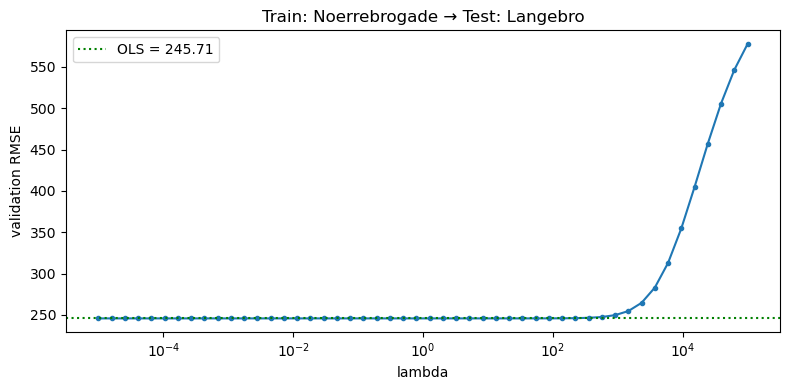

  (intercept only)           val RMSE = 513.28
  temp_x_wd                  val RMSE = 430.02
  hour_24                    val RMSE = 378.54
  hour_8                     val RMSE = 337.52
  hour12_x_wd                val RMSE = 309.50
  dayofyear_1                val RMSE = 289.01
  hour_4_8                   val RMSE = 270.50
  hour4_x_wd                 val RMSE = 262.62
  hour24_x_wd                val RMSE = 257.41
  hour_12                    val RMSE = 255.23
  hour8_x_wd                 val RMSE = 252.34
  wind                       val RMSE = 250.18
  precip                     val RMSE = 248.70
  hour4_8_x_wd               val RMSE = 247.79
  hour_4                     val RMSE = 246.82
  temp                       val RMSE = 246.24
  hour6_x_wd                 val RMSE = 245.79
  precip_x_wd                val RMSE = 245.74
  hour_6                     val RMSE = 245.71
  Selected groups: 18

Train: Noerrebrogade → Test: Amagerbrogade
  best λ=0  val RMSE=245.71  test RMSE=31

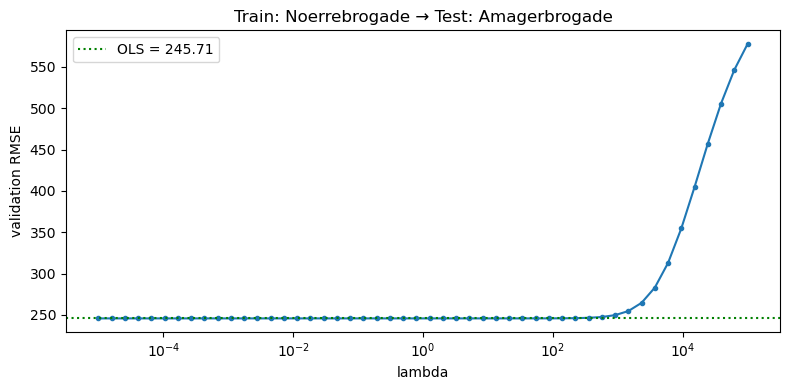

  (intercept only)           val RMSE = 301.62
  temp_x_wd                  val RMSE = 254.24
  hour_24                    val RMSE = 225.33
  hour_8                     val RMSE = 201.57
  hour12_x_wd                val RMSE = 185.31
  dayofyear_1                val RMSE = 174.03
  hour_4_8                   val RMSE = 163.29
  hour4_x_wd                 val RMSE = 158.73
  hour24_x_wd                val RMSE = 155.89
  hour_12                    val RMSE = 154.72
  hour8_x_wd                 val RMSE = 152.89
  wind                       val RMSE = 151.71
  precip                     val RMSE = 150.84
  hour4_8_x_wd               val RMSE = 150.28
  hour_4                     val RMSE = 149.70
  temp                       val RMSE = 149.36
  hour_6                     val RMSE = 149.08
  precip_x_wd                val RMSE = 149.04
  wind_sq                    val RMSE = 149.04
  Selected groups: 18

Train: H_C_Andersens_Boulevard → Test: Dronning_Louises_Bro
  best λ=21.21  val RMSE

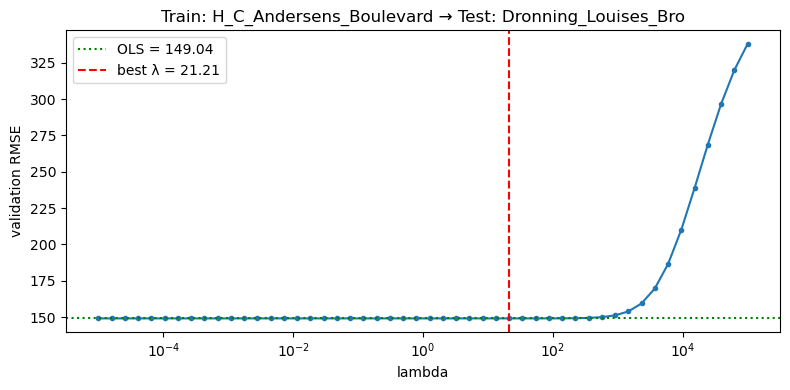

  (intercept only)           val RMSE = 301.62
  temp_x_wd                  val RMSE = 254.24
  hour_24                    val RMSE = 225.33
  hour_8                     val RMSE = 201.57
  hour12_x_wd                val RMSE = 185.31
  dayofyear_1                val RMSE = 174.03
  hour_4_8                   val RMSE = 163.29
  hour4_x_wd                 val RMSE = 158.73
  hour24_x_wd                val RMSE = 155.89
  hour_12                    val RMSE = 154.72
  hour8_x_wd                 val RMSE = 152.89
  wind                       val RMSE = 151.71
  precip                     val RMSE = 150.84
  hour4_8_x_wd               val RMSE = 150.28
  hour_4                     val RMSE = 149.70
  temp                       val RMSE = 149.36
  hour_6                     val RMSE = 149.08
  precip_x_wd                val RMSE = 149.04
  wind_sq                    val RMSE = 149.04
  Selected groups: 18

Train: H_C_Andersens_Boulevard → Test: Torvegade
  best λ=21.21  val RMSE=149.04  te

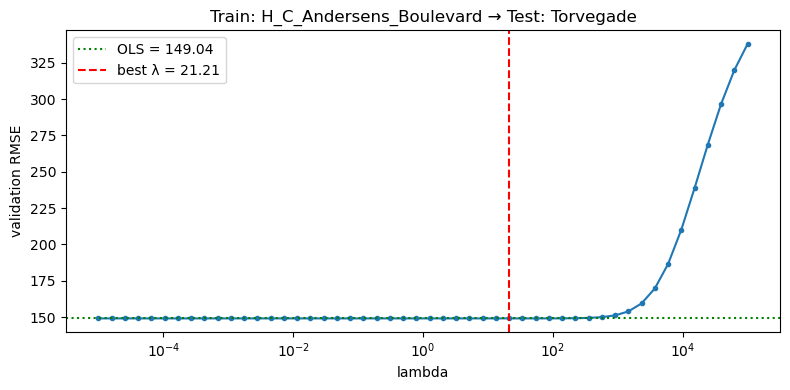

  (intercept only)           val RMSE = 301.62
  temp_x_wd                  val RMSE = 254.24
  hour_24                    val RMSE = 225.33
  hour_8                     val RMSE = 201.57
  hour12_x_wd                val RMSE = 185.31
  dayofyear_1                val RMSE = 174.03
  hour_4_8                   val RMSE = 163.29
  hour4_x_wd                 val RMSE = 158.73
  hour24_x_wd                val RMSE = 155.89
  hour_12                    val RMSE = 154.72
  hour8_x_wd                 val RMSE = 152.89
  wind                       val RMSE = 151.71
  precip                     val RMSE = 150.84
  hour4_8_x_wd               val RMSE = 150.28
  hour_4                     val RMSE = 149.70
  temp                       val RMSE = 149.36
  hour_6                     val RMSE = 149.08
  precip_x_wd                val RMSE = 149.04
  wind_sq                    val RMSE = 149.04
  Selected groups: 18

Train: H_C_Andersens_Boulevard → Test: Noerrebrogade
  best λ=21.21  val RMSE=149.04

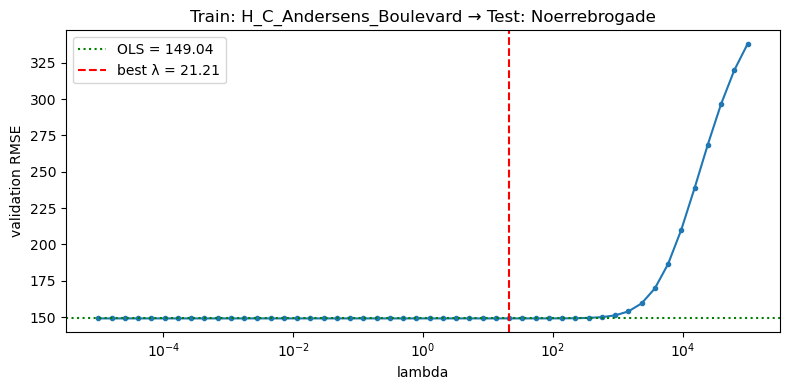

  (intercept only)           val RMSE = 301.62
  temp_x_wd                  val RMSE = 254.24
  hour_24                    val RMSE = 225.33
  hour_8                     val RMSE = 201.57
  hour12_x_wd                val RMSE = 185.31
  dayofyear_1                val RMSE = 174.03
  hour_4_8                   val RMSE = 163.29
  hour4_x_wd                 val RMSE = 158.73
  hour24_x_wd                val RMSE = 155.89
  hour_12                    val RMSE = 154.72
  hour8_x_wd                 val RMSE = 152.89
  wind                       val RMSE = 151.71
  precip                     val RMSE = 150.84
  hour4_8_x_wd               val RMSE = 150.28
  hour_4                     val RMSE = 149.70
  temp                       val RMSE = 149.36
  hour_6                     val RMSE = 149.08
  precip_x_wd                val RMSE = 149.04
  wind_sq                    val RMSE = 149.04
  Selected groups: 18

Station H_C_Andersens_Boulevard
  best λ=21.21  val RMSE=149.04  test RMSE=142.44


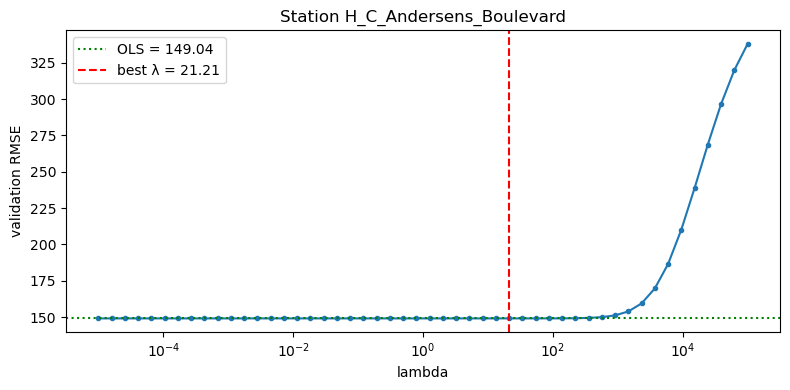

  (intercept only)           val RMSE = 301.62
  temp_x_wd                  val RMSE = 254.24
  hour_24                    val RMSE = 225.33
  hour_8                     val RMSE = 201.57
  hour12_x_wd                val RMSE = 185.31
  dayofyear_1                val RMSE = 174.03
  hour_4_8                   val RMSE = 163.29
  hour4_x_wd                 val RMSE = 158.73
  hour24_x_wd                val RMSE = 155.89
  hour_12                    val RMSE = 154.72
  hour8_x_wd                 val RMSE = 152.89
  wind                       val RMSE = 151.71
  precip                     val RMSE = 150.84
  hour4_8_x_wd               val RMSE = 150.28
  hour_4                     val RMSE = 149.70
  temp                       val RMSE = 149.36
  hour_6                     val RMSE = 149.08
  precip_x_wd                val RMSE = 149.04
  wind_sq                    val RMSE = 149.04
  Selected groups: 18

Train: H_C_Andersens_Boulevard → Test: Langebro
  best λ=21.21  val RMSE=149.04  tes

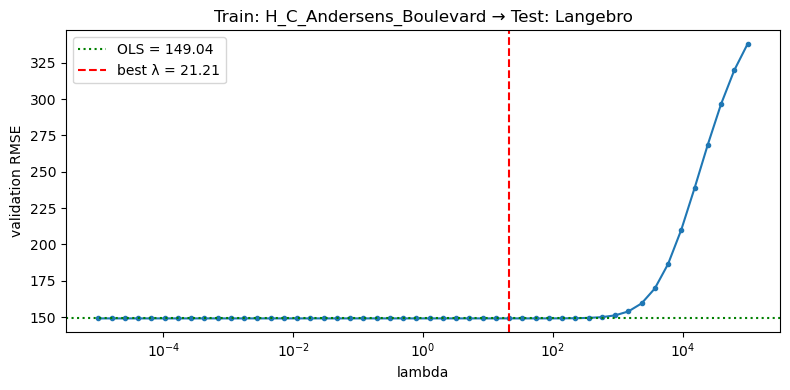

  (intercept only)           val RMSE = 301.62
  temp_x_wd                  val RMSE = 254.24
  hour_24                    val RMSE = 225.33
  hour_8                     val RMSE = 201.57
  hour12_x_wd                val RMSE = 185.31
  dayofyear_1                val RMSE = 174.03
  hour_4_8                   val RMSE = 163.29
  hour4_x_wd                 val RMSE = 158.73
  hour24_x_wd                val RMSE = 155.89
  hour_12                    val RMSE = 154.72
  hour8_x_wd                 val RMSE = 152.89
  wind                       val RMSE = 151.71
  precip                     val RMSE = 150.84
  hour4_8_x_wd               val RMSE = 150.28
  hour_4                     val RMSE = 149.70
  temp                       val RMSE = 149.36
  hour_6                     val RMSE = 149.08
  precip_x_wd                val RMSE = 149.04
  wind_sq                    val RMSE = 149.04
  Selected groups: 18

Train: H_C_Andersens_Boulevard → Test: Amagerbrogade
  best λ=21.21  val RMSE=149.04

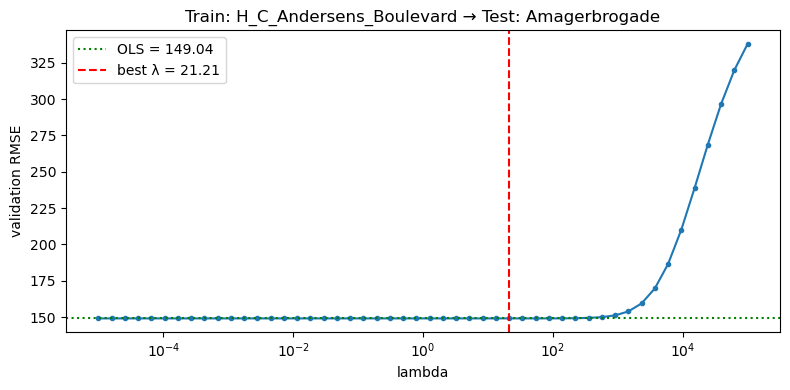

  (intercept only)           val RMSE = 264.90
  temp_x_wd                  val RMSE = 222.42
  hour_24                    val RMSE = 196.28
  hour_8                     val RMSE = 175.69
  hour12_x_wd                val RMSE = 161.85
  dayofyear_1                val RMSE = 151.81
  hour_4_8                   val RMSE = 142.30
  hour4_x_wd                 val RMSE = 138.47
  hour24_x_wd                val RMSE = 135.80
  wind                       val RMSE = 134.71
  hour_12                    val RMSE = 133.63
  hour8_x_wd                 val RMSE = 132.15
  precip                     val RMSE = 131.43
  hour4_8_x_wd               val RMSE = 130.92
  hour_4                     val RMSE = 130.41
  temp                       val RMSE = 130.11
  hour_6                     val RMSE = 129.92
  hour6_x_wd                 val RMSE = 129.90
  precip_x_wd                val RMSE = 129.89
  is_weekend                 val RMSE = 129.88
  wind_x_wd                  val RMSE = 129.80
  is_holiday 

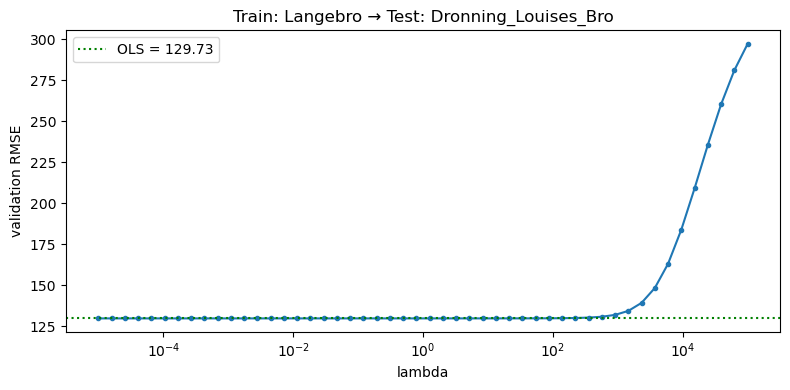

  (intercept only)           val RMSE = 264.90
  temp_x_wd                  val RMSE = 222.42
  hour_24                    val RMSE = 196.28
  hour_8                     val RMSE = 175.69
  hour12_x_wd                val RMSE = 161.85
  dayofyear_1                val RMSE = 151.81
  hour_4_8                   val RMSE = 142.30
  hour4_x_wd                 val RMSE = 138.47
  hour24_x_wd                val RMSE = 135.80
  wind                       val RMSE = 134.71
  hour_12                    val RMSE = 133.63
  hour8_x_wd                 val RMSE = 132.15
  precip                     val RMSE = 131.43
  hour4_8_x_wd               val RMSE = 130.92
  hour_4                     val RMSE = 130.41
  temp                       val RMSE = 130.11
  hour_6                     val RMSE = 129.92
  hour6_x_wd                 val RMSE = 129.90
  precip_x_wd                val RMSE = 129.89
  is_weekend                 val RMSE = 129.88
  wind_x_wd                  val RMSE = 129.80
  is_holiday 

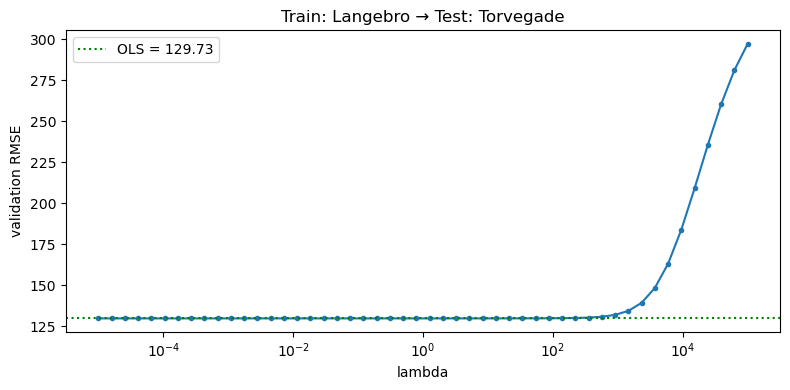

  (intercept only)           val RMSE = 264.90
  temp_x_wd                  val RMSE = 222.42
  hour_24                    val RMSE = 196.28
  hour_8                     val RMSE = 175.69
  hour12_x_wd                val RMSE = 161.85
  dayofyear_1                val RMSE = 151.81
  hour_4_8                   val RMSE = 142.30
  hour4_x_wd                 val RMSE = 138.47
  hour24_x_wd                val RMSE = 135.80
  wind                       val RMSE = 134.71
  hour_12                    val RMSE = 133.63
  hour8_x_wd                 val RMSE = 132.15
  precip                     val RMSE = 131.43
  hour4_8_x_wd               val RMSE = 130.92
  hour_4                     val RMSE = 130.41
  temp                       val RMSE = 130.11
  hour_6                     val RMSE = 129.92
  hour6_x_wd                 val RMSE = 129.90
  precip_x_wd                val RMSE = 129.89
  is_weekend                 val RMSE = 129.88
  wind_x_wd                  val RMSE = 129.80
  is_holiday 

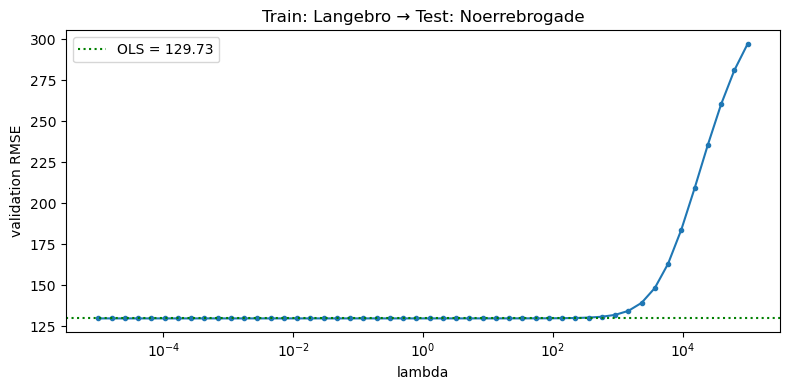

  (intercept only)           val RMSE = 264.90
  temp_x_wd                  val RMSE = 222.42
  hour_24                    val RMSE = 196.28
  hour_8                     val RMSE = 175.69
  hour12_x_wd                val RMSE = 161.85
  dayofyear_1                val RMSE = 151.81
  hour_4_8                   val RMSE = 142.30
  hour4_x_wd                 val RMSE = 138.47
  hour24_x_wd                val RMSE = 135.80
  wind                       val RMSE = 134.71
  hour_12                    val RMSE = 133.63
  hour8_x_wd                 val RMSE = 132.15
  precip                     val RMSE = 131.43
  hour4_8_x_wd               val RMSE = 130.92
  hour_4                     val RMSE = 130.41
  temp                       val RMSE = 130.11
  hour_6                     val RMSE = 129.92
  hour6_x_wd                 val RMSE = 129.90
  precip_x_wd                val RMSE = 129.89
  is_weekend                 val RMSE = 129.88
  wind_x_wd                  val RMSE = 129.80
  is_holiday 

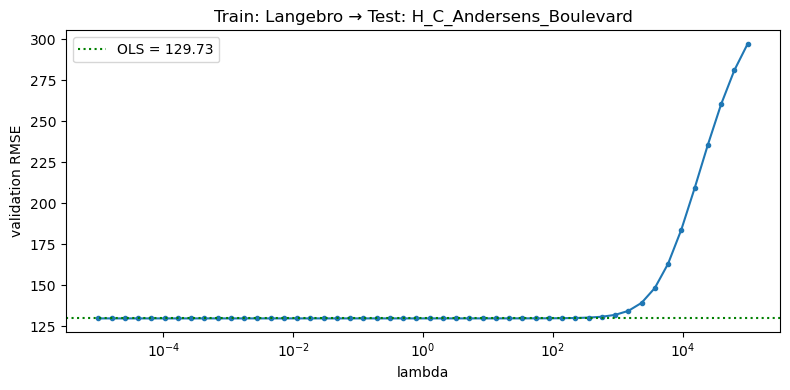

  (intercept only)           val RMSE = 264.90
  temp_x_wd                  val RMSE = 222.42
  hour_24                    val RMSE = 196.28
  hour_8                     val RMSE = 175.69
  hour12_x_wd                val RMSE = 161.85
  dayofyear_1                val RMSE = 151.81
  hour_4_8                   val RMSE = 142.30
  hour4_x_wd                 val RMSE = 138.47
  hour24_x_wd                val RMSE = 135.80
  wind                       val RMSE = 134.71
  hour_12                    val RMSE = 133.63
  hour8_x_wd                 val RMSE = 132.15
  precip                     val RMSE = 131.43
  hour4_8_x_wd               val RMSE = 130.92
  hour_4                     val RMSE = 130.41
  temp                       val RMSE = 130.11
  hour_6                     val RMSE = 129.92
  hour6_x_wd                 val RMSE = 129.90
  precip_x_wd                val RMSE = 129.89
  is_weekend                 val RMSE = 129.88
  wind_x_wd                  val RMSE = 129.80
  is_holiday 

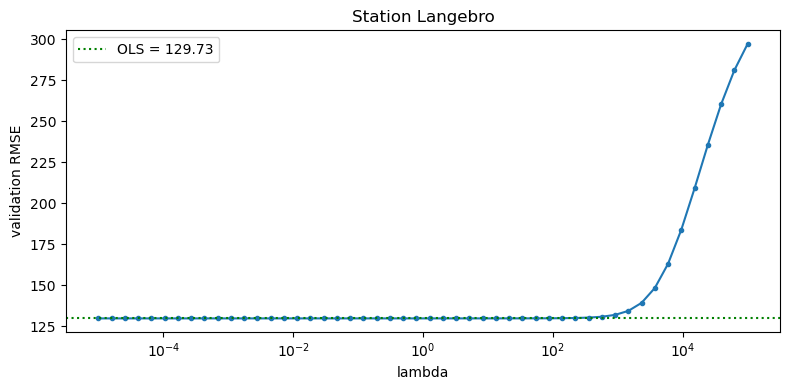

  (intercept only)           val RMSE = 264.90
  temp_x_wd                  val RMSE = 222.42
  hour_24                    val RMSE = 196.28
  hour_8                     val RMSE = 175.69
  hour12_x_wd                val RMSE = 161.85
  dayofyear_1                val RMSE = 151.81
  hour_4_8                   val RMSE = 142.30
  hour4_x_wd                 val RMSE = 138.47
  hour24_x_wd                val RMSE = 135.80
  wind                       val RMSE = 134.71
  hour_12                    val RMSE = 133.63
  hour8_x_wd                 val RMSE = 132.15
  precip                     val RMSE = 131.43
  hour4_8_x_wd               val RMSE = 130.92
  hour_4                     val RMSE = 130.41
  temp                       val RMSE = 130.11
  hour_6                     val RMSE = 129.92
  hour6_x_wd                 val RMSE = 129.90
  precip_x_wd                val RMSE = 129.89
  is_weekend                 val RMSE = 129.88
  wind_x_wd                  val RMSE = 129.80
  is_holiday 

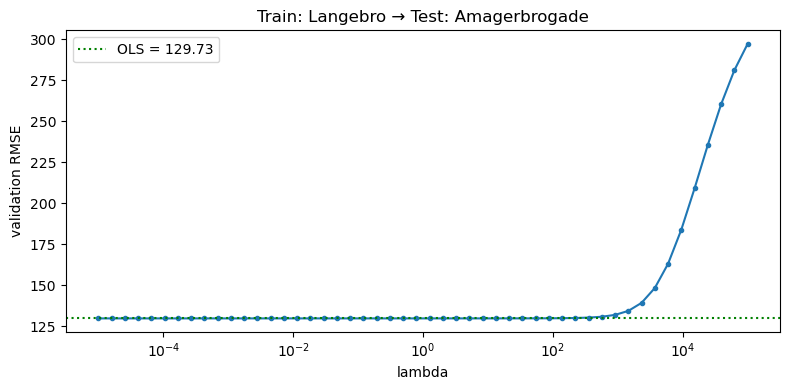

  (intercept only)           val RMSE = 230.94
  temp_x_wd                  val RMSE = 195.26
  hour_24                    val RMSE = 173.39
  hour_8                     val RMSE = 156.03
  hour12_x_wd                val RMSE = 144.42
  dayofyear_1                val RMSE = 135.95
  hour_4_8                   val RMSE = 128.46
  hour4_x_wd                 val RMSE = 125.40
  hour24_x_wd                val RMSE = 123.28
  hour_12                    val RMSE = 122.42
  hour8_x_wd                 val RMSE = 121.16
  wind                       val RMSE = 120.35
  precip                     val RMSE = 119.79
  hour4_8_x_wd               val RMSE = 119.43
  hour_4                     val RMSE = 119.02
  temp                       val RMSE = 118.80
  hour_6                     val RMSE = 118.60
  dayofyear_2                val RMSE = 118.57
  precip_x_wd                val RMSE = 118.56
  hour6_x_wd                 val RMSE = 118.54
  wind_sq                    val RMSE = 118.54
  Selected gr

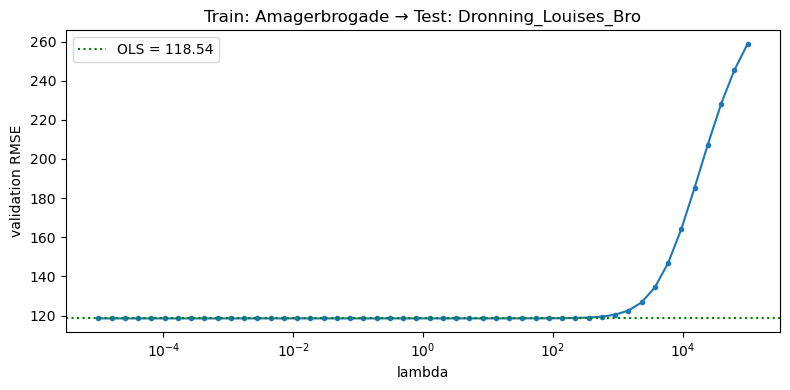

  (intercept only)           val RMSE = 230.94
  temp_x_wd                  val RMSE = 195.26
  hour_24                    val RMSE = 173.39
  hour_8                     val RMSE = 156.03
  hour12_x_wd                val RMSE = 144.42
  dayofyear_1                val RMSE = 135.95
  hour_4_8                   val RMSE = 128.46
  hour4_x_wd                 val RMSE = 125.40
  hour24_x_wd                val RMSE = 123.28
  hour_12                    val RMSE = 122.42
  hour8_x_wd                 val RMSE = 121.16
  wind                       val RMSE = 120.35
  precip                     val RMSE = 119.79
  hour4_8_x_wd               val RMSE = 119.43
  hour_4                     val RMSE = 119.02
  temp                       val RMSE = 118.80
  hour_6                     val RMSE = 118.60
  dayofyear_2                val RMSE = 118.57
  precip_x_wd                val RMSE = 118.56
  hour6_x_wd                 val RMSE = 118.54
  wind_sq                    val RMSE = 118.54
  Selected gr

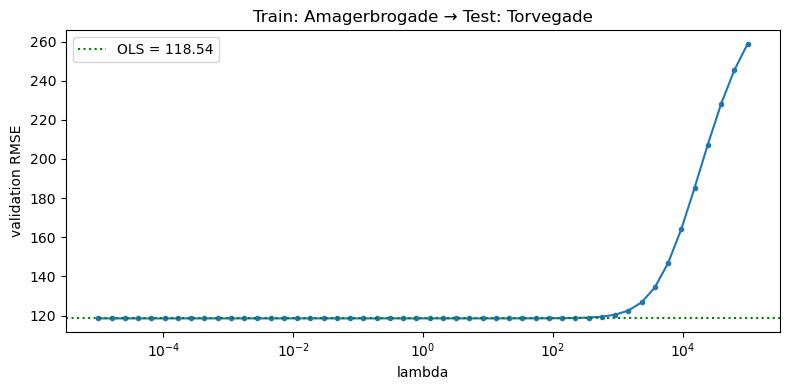

  (intercept only)           val RMSE = 230.94
  temp_x_wd                  val RMSE = 195.26
  hour_24                    val RMSE = 173.39
  hour_8                     val RMSE = 156.03
  hour12_x_wd                val RMSE = 144.42
  dayofyear_1                val RMSE = 135.95
  hour_4_8                   val RMSE = 128.46
  hour4_x_wd                 val RMSE = 125.40
  hour24_x_wd                val RMSE = 123.28
  hour_12                    val RMSE = 122.42
  hour8_x_wd                 val RMSE = 121.16
  wind                       val RMSE = 120.35
  precip                     val RMSE = 119.79
  hour4_8_x_wd               val RMSE = 119.43
  hour_4                     val RMSE = 119.02
  temp                       val RMSE = 118.80
  hour_6                     val RMSE = 118.60
  dayofyear_2                val RMSE = 118.57
  precip_x_wd                val RMSE = 118.56
  hour6_x_wd                 val RMSE = 118.54
  wind_sq                    val RMSE = 118.54
  Selected gr

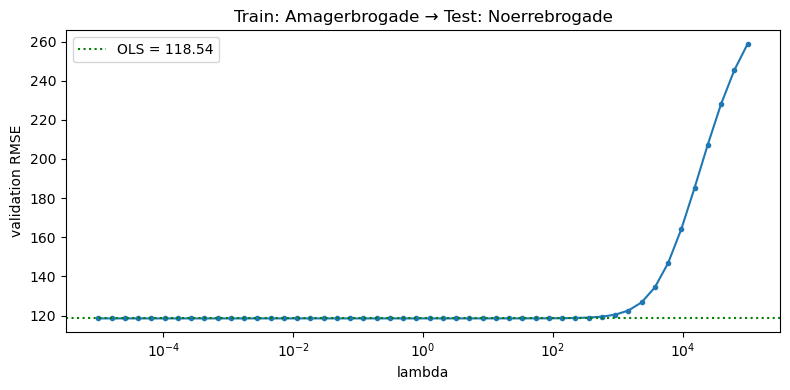

  (intercept only)           val RMSE = 230.94
  temp_x_wd                  val RMSE = 195.26
  hour_24                    val RMSE = 173.39
  hour_8                     val RMSE = 156.03
  hour12_x_wd                val RMSE = 144.42
  dayofyear_1                val RMSE = 135.95
  hour_4_8                   val RMSE = 128.46
  hour4_x_wd                 val RMSE = 125.40
  hour24_x_wd                val RMSE = 123.28
  hour_12                    val RMSE = 122.42
  hour8_x_wd                 val RMSE = 121.16
  wind                       val RMSE = 120.35
  precip                     val RMSE = 119.79
  hour4_8_x_wd               val RMSE = 119.43
  hour_4                     val RMSE = 119.02
  temp                       val RMSE = 118.80
  hour_6                     val RMSE = 118.60
  dayofyear_2                val RMSE = 118.57
  precip_x_wd                val RMSE = 118.56
  hour6_x_wd                 val RMSE = 118.54
  wind_sq                    val RMSE = 118.54
  Selected gr

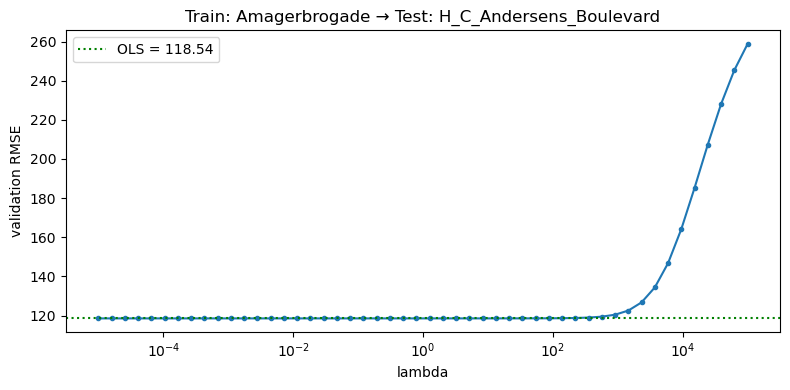

  (intercept only)           val RMSE = 230.94
  temp_x_wd                  val RMSE = 195.26
  hour_24                    val RMSE = 173.39
  hour_8                     val RMSE = 156.03
  hour12_x_wd                val RMSE = 144.42
  dayofyear_1                val RMSE = 135.95
  hour_4_8                   val RMSE = 128.46
  hour4_x_wd                 val RMSE = 125.40
  hour24_x_wd                val RMSE = 123.28
  hour_12                    val RMSE = 122.42
  hour8_x_wd                 val RMSE = 121.16
  wind                       val RMSE = 120.35
  precip                     val RMSE = 119.79
  hour4_8_x_wd               val RMSE = 119.43
  hour_4                     val RMSE = 119.02
  temp                       val RMSE = 118.80
  hour_6                     val RMSE = 118.60
  dayofyear_2                val RMSE = 118.57
  precip_x_wd                val RMSE = 118.56
  hour6_x_wd                 val RMSE = 118.54
  wind_sq                    val RMSE = 118.54
  Selected gr

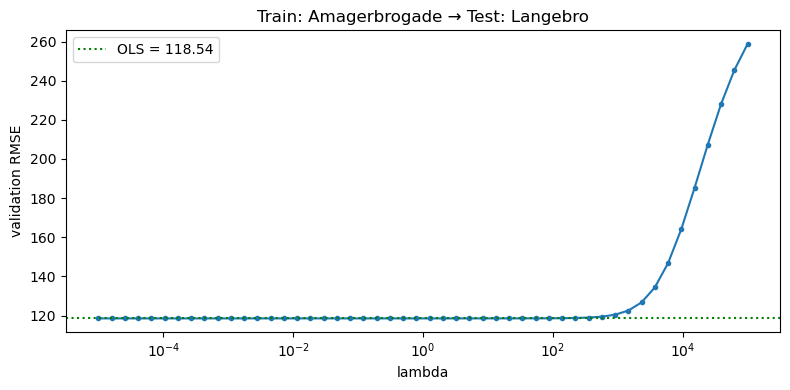

  (intercept only)           val RMSE = 230.94
  temp_x_wd                  val RMSE = 195.26
  hour_24                    val RMSE = 173.39
  hour_8                     val RMSE = 156.03
  hour12_x_wd                val RMSE = 144.42
  dayofyear_1                val RMSE = 135.95
  hour_4_8                   val RMSE = 128.46
  hour4_x_wd                 val RMSE = 125.40
  hour24_x_wd                val RMSE = 123.28
  hour_12                    val RMSE = 122.42
  hour8_x_wd                 val RMSE = 121.16
  wind                       val RMSE = 120.35
  precip                     val RMSE = 119.79
  hour4_8_x_wd               val RMSE = 119.43
  hour_4                     val RMSE = 119.02
  temp                       val RMSE = 118.80
  hour_6                     val RMSE = 118.60
  dayofyear_2                val RMSE = 118.57
  precip_x_wd                val RMSE = 118.56
  hour6_x_wd                 val RMSE = 118.54
  wind_sq                    val RMSE = 118.54
  Selected gr

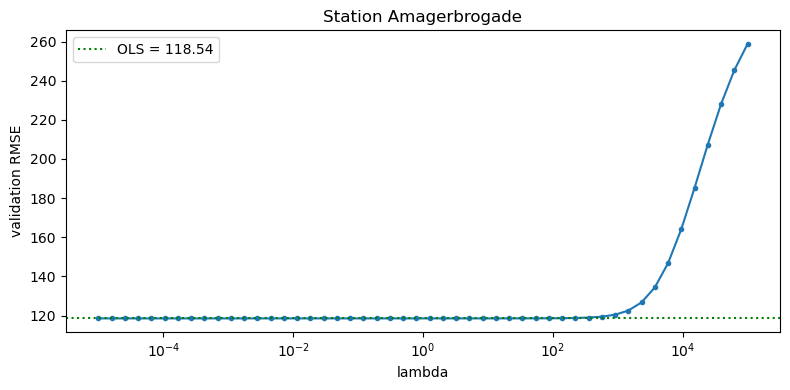

In [51]:
for station1 in stations:
    for station2 in stations:
        calculate_and_plot_rmse(station1, station2)



## Conclusion

- Which individual experiments beat the reference baseline?
- Which combination did forward selection pick?
- How much did val RMSE drop overall? Test RMSE?
- Is the residual structure at hours 8/17 reduced? (Compare MAE numbers above.)
- What remains as potential improvements (lag features, station-specific effects)?
